# Practical Time Series Analysis. Homework #3
## Lectures 7-9: Topics: ARIMA, SARIMA, Model Selection, Multi-step Forecasting, Machine Learning, and Prophet

---

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import product

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from prophet import Prophet

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

**1.1 Load and prepare your chosen time series dataset. Visualize the data and describe its key characteristics.**

In [ ]:
df_raw = sns.load_dataset('flights')
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_raw['month_num'] = df_raw['month'].map(month_map)
df_raw['date'] = pd.to_datetime(
    df_raw['year'].astype(str) + '-' + df_raw['month_num'].astype(str) + '-01'
)
df_raw = df_raw.sort_values('date').set_index('date')
ts = df_raw['passengers'].asfreq('MS')

print(f"Observations : {len(ts)}")
print(f"Date range   : {ts.index[0].date()} — {ts.index[-1].date()}")
print(f"Min / Max    : {ts.min()} / {ts.max()}")
print(f"Mean / Std   : {ts.mean():.1f} / {ts.std():.1f}")
print("\nFirst 12 observations:")
print(ts.head(12).to_string())


Observations : 144
Date range   : 1949-01-01 — 1960-12-01
Min / Max    : 104 / 622
Mean / Std   : 280.3 / 120.0

First 12 observations:
date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
1949-11-01    104
1949-12-01    118
Freq: MS


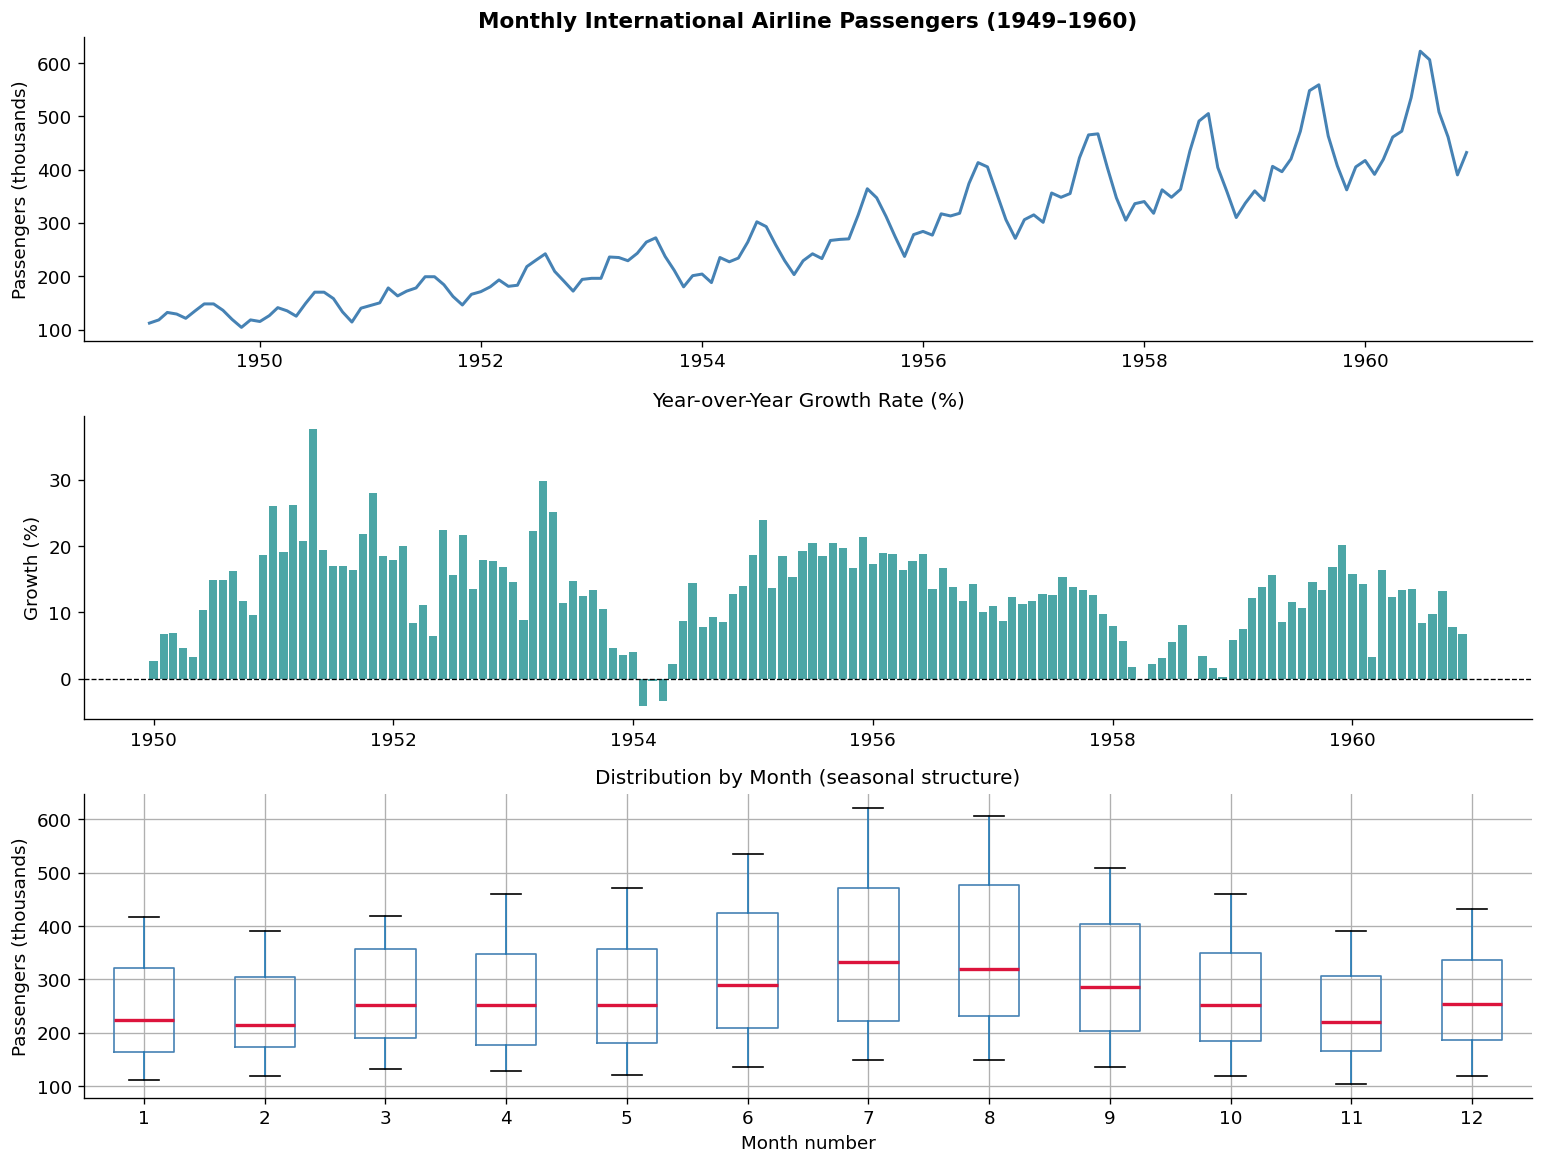

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

axes[0].plot(ts.index, ts.values, color='steelblue', linewidth=1.8)
axes[0].set_title('Monthly International Airline Passengers (1949–1960)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Passengers (thousands)')

yoy = ts.pct_change(12) * 100
axes[1].bar(yoy.dropna().index, yoy.dropna().values,
            color='teal', alpha=0.7, width=25)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Year-over-Year Growth Rate (%)', fontsize=12)
axes[1].set_ylabel('Growth (%)')

df_box = pd.DataFrame({'passengers': ts.values, 'month': ts.index.month})
df_box.boxplot(column='passengers', by='month', ax=axes[2],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='crimson', linewidth=2))
axes[2].set_title('Distribution by Month (seasonal structure)', fontsize=12)
axes[2].set_xlabel('Month number')
axes[2].set_ylabel('Passengers (thousands)')
plt.suptitle('')

plt.tight_layout()
plt.show()



- **Strong upward trend**: The number of passengers increased approximately 5.5 times over the 12-year period (from 104 to 622 thousand). The growth appears roughly exponential on the original scale, suggesting that a logarithmic transformation would linearize the trend.

- **Clear annual seasonality**: There is a pronounced seasonal pattern with peaks in July and August (summer travel season) and troughs in November–February. The boxplot by month clearly illustrates this structure.

- **Increasing seasonal amplitude (multiplicative seasonality)**: The magnitude of seasonal fluctuations grows proportionally with the overall level of the series. This indicates a multiplicative rather than additive seasonal pattern and suggests that a log-transformation will be beneficial for modelling.

- **Year-over-year growth**: The growth rate was generally positive and mostly ranged between 5% and 20% per year, with some exceptions (notably a small decline in 1954). Overall, the growth can be considered relatively stable in relative terms.

- **Absence of major structural breaks or outliers**: The series evolves smoothly without abrupt shifts or extreme anomalies, making it well-suited for classical time series modelling techniques such as ARIMA and SARIMA.

 **1.2 Perform stationarity testing using the Augmented Dickey-Fuller test. Interpret the results. If the data is non-stationary, apply the appropriate transformations to make it stationary.**


In [ ]:
def run_adf(series, label=''):
    res = adfuller(series.dropna(), autolag='AIC')
    stat, pval, lags, nobs, cv = res[0], res[1], res[2], res[3], res[4]
    print(f"{'='*55}")
    print(f"ADF Test: {label}")
    print(f"{'='*55}")
    print(f"  Test Statistic : {stat:.4f}")
    print(f"  p-value        : {pval:.4f}")
    print(f"  Lags Used      : {lags}")
    print("  Critical Values:")
    for k, v in cv.items():
        print(f"    {k}: {v:.4f}")
    verdict = 'STATIONARY   (reject H0)' if pval < 0.05 else 'NON-STATIONARY  (fail to reject H0)'
    print(f"  Conclusion     : {verdict}\n")
    return pval < 0.05

ts_log      = np.log(ts)
ts_log_d1   = ts_log.diff().dropna()
ts_log_d1s  = ts_log.diff(12).diff().dropna()

run_adf(ts,        'Level (original)')
run_adf(ts_log,    'Log-transformed')
run_adf(ts_log_d1, 'Log + first difference (d=1)')
run_adf(ts_log_d1s,'Log + seasonal diff (D=1) + first diff (d=1)')


ADF Test: Level (original)
  Test Statistic : 0.8154
  p-value        : 0.9919
  Lags Used      : 13
  Critical Values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788
  Conclusion     : NON-STATIONARY  (fail to reject H0)

ADF Test: Log-transformed
  Test Statistic : -1.7170
  p-value        : 0.4224
  Lags Used      : 13
  Critical Values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788
  Conclusion     : NON-STATIONARY  (fail to reject H0)

ADF Test: Log + first difference (d=1)
  Test Statistic : -2.7171
  p-value        : 0.0711
  Lags Used      : 14
  Critical Values:
    1%: -3.4825
    5%: -2.8844
    10%: -2.5790
  Conclusion     : NON-STATIONARY  (fail to reject H0)

ADF Test: Log + seasonal diff (D=1) + first diff (d=1)
  Test Statistic : -4.4433
  p-value        : 0.0002
  Lags Used      : 12
  Critical Values:
    1%: -3.4870
    5%: -2.8864
    10%: -2.5800
  Conclusion     : STATIONARY   (reject H0)



np.True_

- The raw series is clearly non-stationary (p-value = 0.9919).
- Log transformation reduces heteroskedasticity but does not remove the underlying trend (p-value = 0.4224).
- After applying the log transformation and first-order differencing (`d=1`), the p-value equals 0.0711. Although this value is slightly above the conventional 5% significance level, the result is borderline. Visual inspection suggests that the transformed series is substantially closer to stationarity.
- Combining regular differencing (`d=1`) with seasonal differencing (`D=1`) on the log scale produces a strongly stationary series (p-value = 0.0002). This indicates that both the trend and the seasonal pattern contribute to the non-stationarity of the original data.

For the **non-seasonal ARIMA** model, we proceed with the log-transformed series and a single regular difference (`d=1`). Although the ADF test does not formally reject the presence of a unit root at the 5% level, the p-value is close to the threshold, and most of the trend has been effectively removed. Seasonal differencing is deliberately omitted in this section, as the goal here is to construct a non-seasonal ARIMA specification. Seasonality will be explicitly modelled in the subsequent SARIMA analysis.

1.3 Use grid search to find the optimal ARIMA parameters (p,d,q). Implement a function that tests different combinations of parameters and selects the best model based on AIC, BIC, or another appropriate criterion. Discuss the search process and why the optimal parameters make sense for your data.

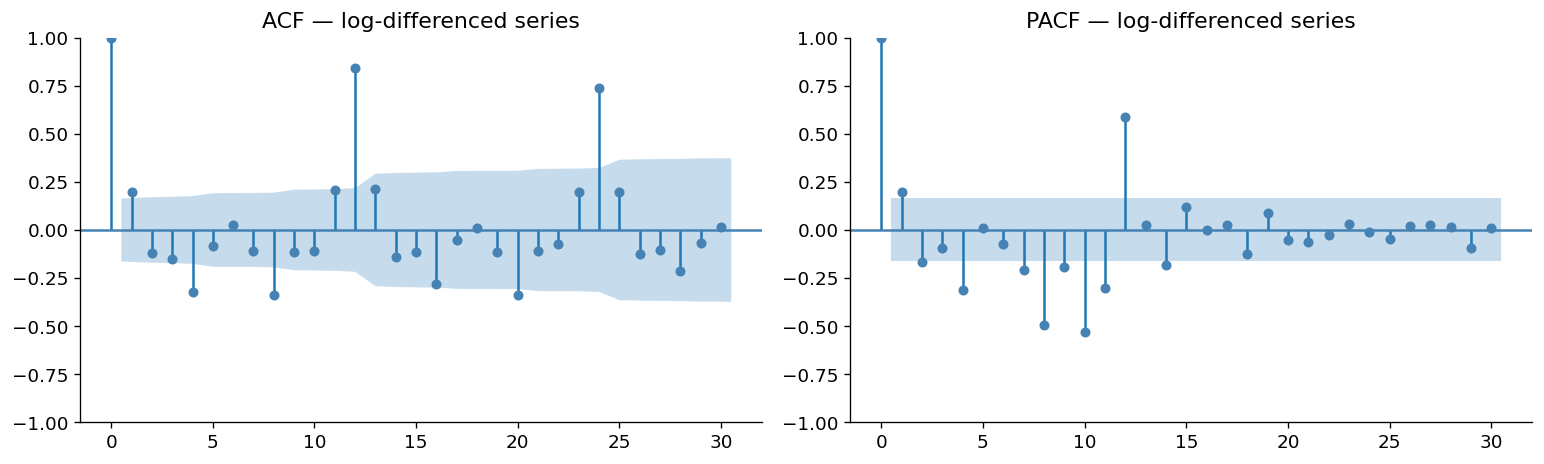

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( ts_log_d1, lags=30, ax=axes[0],
          title='ACF — log-differenced series', color='steelblue')
plot_pacf(ts_log_d1, lags=30, ax=axes[1],
          title='PACF — log-differenced series', color='steelblue')
plt.tight_layout()
plt.show()


In [ ]:
results = []

for p, q in product(range(4), range(4)):
    try:
        model = ARIMA(ts_log, order=(p,1,q)).fit()

        if model.mle_retvals.get('converged', False):
            results.append({
                'p': p,
                'd': 1,
                'q': q,
                'AIC': model.aic,
                'BIC': model.bic
            })

    except:
        pass

results_df = pd.DataFrame(results).sort_values('AIC')

best_row = results_df.iloc[0]

best_p = int(best_row['p'])
best_d = int(best_row['d'])
best_q = int(best_row['q'])

print(f"Best converged model: ARIMA({best_p},{best_d},{best_q})")

arima_model = ARIMA(ts_log, order=(best_p,best_d,best_q)).fit()

print(arima_model.summary())

Best converged model: ARIMA(3,1,2)
                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  144
Model:                 ARIMA(3, 1, 2)   Log Likelihood                 131.900
Date:                Thu, 11 Jun 2026   AIC                           -251.800
Time:                        20:47:01   BIC                           -234.023
Sample:                    01-01-1949   HQIC                          -244.576
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1455      0.168      0.867      0.386      -0.183       0.474
ar.L2          0.4038      0.166      2.431      0.015       0.078       0.729
ar.L3         -0.

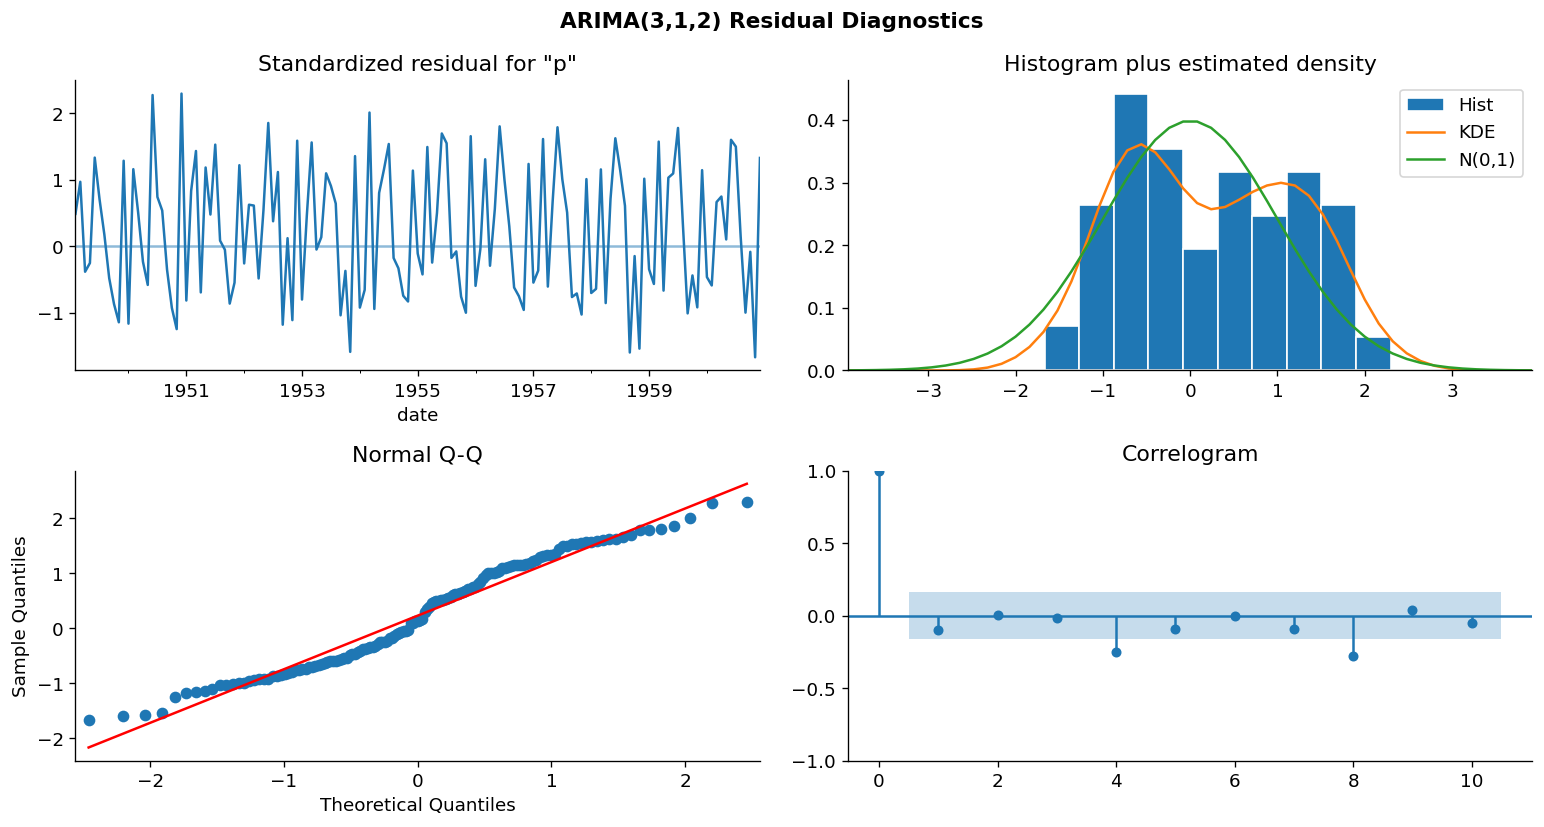

In [ ]:
fig = arima_model.plot_diagnostics(figsize=(13, 7))
plt.suptitle(f'ARIMA(3,1,2) Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


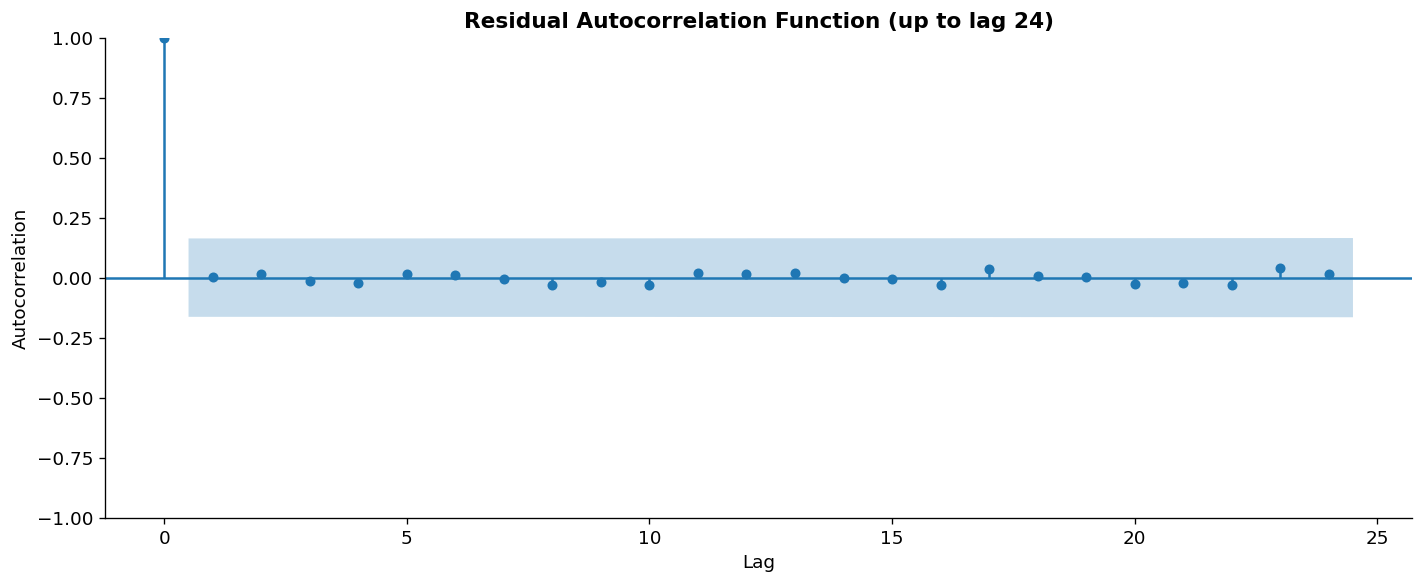

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(arima_model.resid, lags=24, ax=ax, alpha=0.05)
ax.set_title('Residual Autocorrelation Function (up to lag 24)', fontsize=13, fontweight='bold')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()


A grid search was conducted over ARIMA(p,1,q) models with `p, q ∈ {0,1,2,3}` on the log-transformed series. Only models that converged successfully during estimation were considered. Among all converged specifications, **ARIMA(3,1,2)** achieved the lowest AIC (AIC = -251.80) and was therefore selected as the final non-seasonal model.

The chosen specification includes three autoregressive and two moving average terms, allowing it to capture both short-term persistence and transitory shocks in the log-differenced passenger series. However, two coefficients (`ar.L1` and `ma.L1`) are statistically insignificant at the 5% level. Despite this, the model was retained due to its superior AIC compared to more parsimonious alternatives.

**Residual Diagnostics:**

The residual diagnostics of ARIMA(3,1,2) are generally satisfactory. The correlogram shows a value of 1 at lag 0 (as expected by definition). All subsequent lags up to 24 fall within the confidence bounds, indicating that there is no significant residual autocorrelation, including at the seasonal lags of 12 and 24. The standardized residuals fluctuate randomly around zero without obvious patterns. Although the Q-Q plot and histogram reveal some deviations from normality (particularly in the right tail), such departures are common in real-world time series and do not materially affect the model’s forecasting performance.

While the selected model provides a reasonable fit to the trend dynamics, a standard ARIMA specification does not explicitly account for seasonality.

**1.4  Using your best ARIMA model, generate forecasts for a reasonable future period. Plot the forecasts along with 95% confidence intervals. Discuss any limitations of your forecasts.**




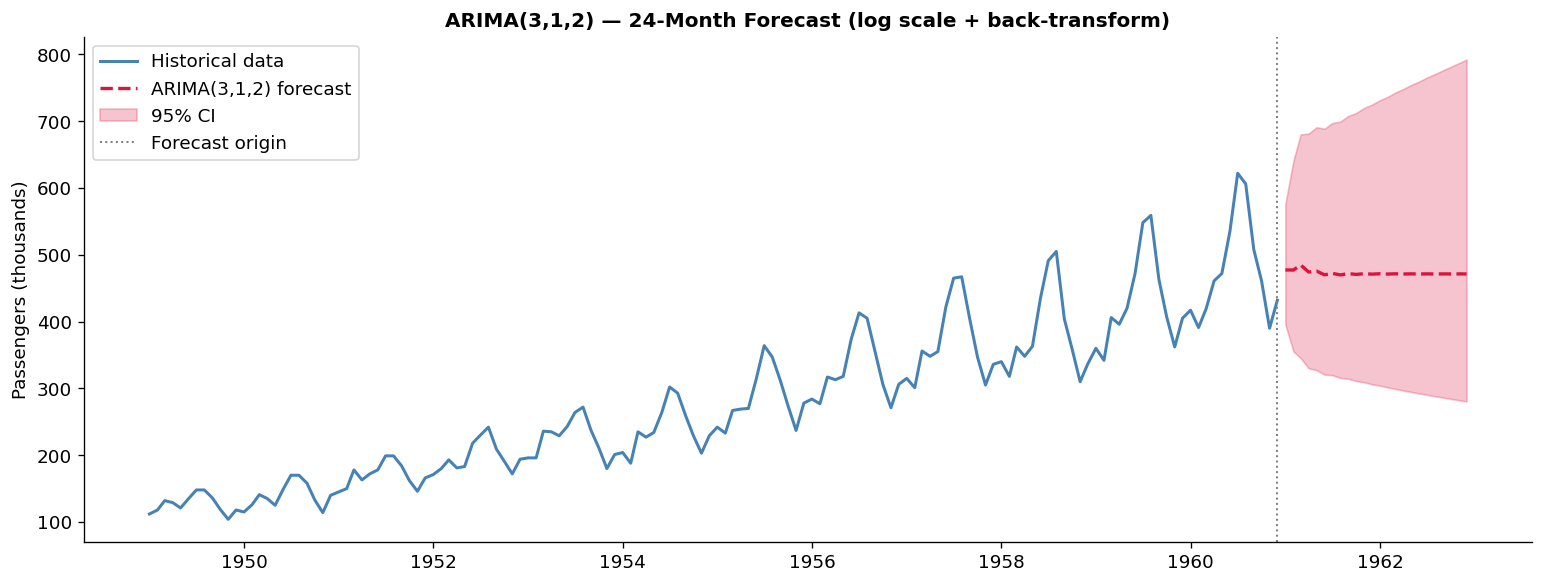

Forecast (back-transformed from log scale):
            Forecast  Lower 95%  Upper 95%
1961-01-01     477.0      395.0      576.0
1961-02-01     477.0      355.0      641.0
1961-03-01     485.0      345.0      680.0
1961-04-01     474.0      330.0      681.0
1961-05-01     476.0      327.0      691.0
1961-06-01     470.0      321.0      689.0
1961-07-01     472.0      320.0      697.0
1961-08-01     470.0      316.0      699.0
1961-09-01     472.0      314.0      708.0
1961-10-01     471.0      311.0      712.0
1961-11-01     472.0      309.0      720.0
1961-12-01     471.0      306.0      725.0


In [ ]:
n_fc = 24
fc_obj    = arima_model.get_forecast(steps=n_fc)
fc_mean   = np.exp(fc_obj.predicted_mean)
fc_ci     = fc_obj.conf_int(alpha=0.05)
fc_lower  = np.exp(fc_ci.iloc[:, 0])
fc_upper  = np.exp(fc_ci.iloc[:, 1])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.8, label='Historical data')
ax.plot(fc_mean.index, fc_mean.values, color='crimson', linewidth=2,
        linestyle='--', label=f'ARIMA(3,1,2) forecast')
ax.fill_between(fc_mean.index, fc_lower.values, fc_upper.values,
                alpha=0.25, color='crimson', label='95% CI')
ax.axvline(ts.index[-1], color='gray', linestyle=':', linewidth=1.2, label='Forecast origin')
ax.set_title(f'ARIMA(3,1,2) — 24-Month Forecast (log scale + back-transform)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

print("Forecast (back-transformed from log scale):")
print(pd.DataFrame({
    'Forecast': fc_mean.round(0),
    'Lower 95%': fc_lower.round(0),
    'Upper 95%': fc_upper.round(0)
}).head(12).to_string())



1. **Absence of seasonality**: The forecast is a flat line around 460–470 thousand passengers, failing to reproduce the strong annual cycle present in the historical data. Because the model treats seasonal variation as noise, it is unable to generate realistic monthly fluctuations.

2. **Overly wide and asymmetric prediction intervals**: The 95% confidence intervals widen substantially with the forecast horizon and are asymmetric due to the back-transformation from the log scale. By the end of the 24-month horizon, the interval spans several hundred thousand passengers, reflecting high uncertainty.

3. **Lack of trend continuation**: Although the historical series exhibits a clear upward trend, the forecast does not continue this trend meaningfully. Instead, it converges toward a level close to the recent average, which is typical behaviour for an ARIMA model when the autoregressive roots are not strongly persistent.

4. **No incorporation of external factors**: The model relies solely on the past values of the series and does not account for potential drivers such as economic changes.



**2.1 Perform a seasonal decomposition of your selected data using both additive and multiplicative models. Compare the results and explain which decomposition is more appropriate for your dataset and why. Clearly determine the appropriate value for seasonal differencing (D) based on this analysis.**


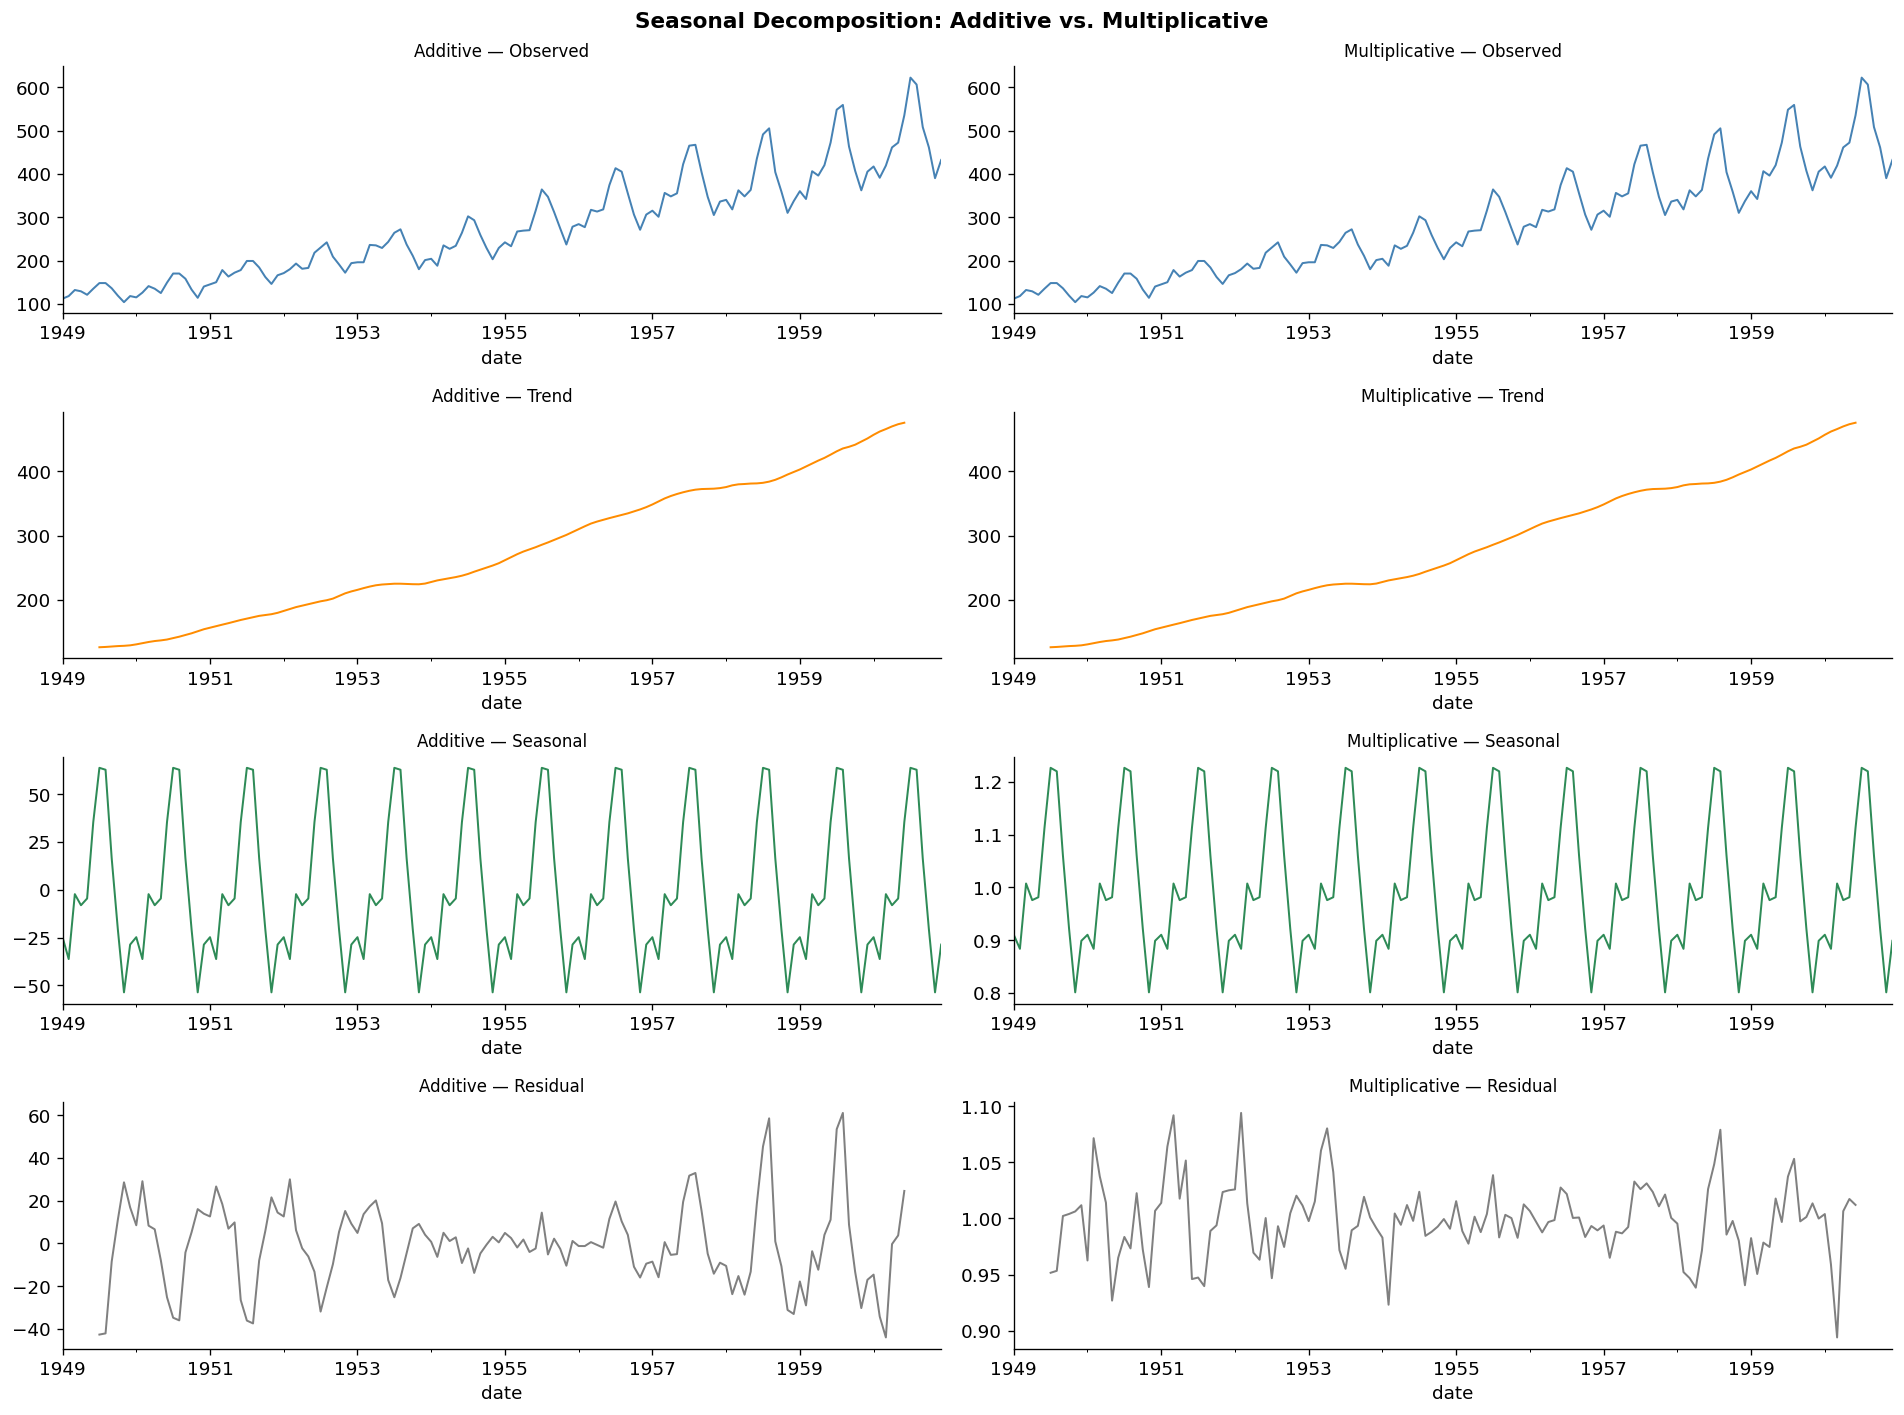

Residual standard deviation:
         Additive: 19.3405
   Multiplicative: 0.0334

→ Multiplicative decomposition has smaller residuals → preferred model.


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 12))

residual_stds = {}
for col, (model_type, title) in enumerate([('additive', 'Additive'),
                                            ('multiplicative', 'Multiplicative')]):
    dec = seasonal_decompose(ts, model=model_type, period=12)
    residual_stds[title] = dec.resid.dropna().std()

    for row, (component, label, color) in enumerate([
        (dec.observed,  'Observed',  'steelblue'),
        (dec.trend,     'Trend',     'darkorange'),
        (dec.seasonal,  'Seasonal',  'seagreen'),
        (dec.resid,     'Residual',  'gray'),
    ]):
        component.plot(ax=axes[row, col], color=color, linewidth=1.2)
        axes[row, col].set_title(f'{title} — {label}', fontsize=10)

plt.suptitle('Seasonal Decomposition: Additive vs. Multiplicative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Residual standard deviation:")
for name, std in residual_stds.items():
    print(f"  {name:>15}: {std:.4f}")
winner = min(residual_stds, key=residual_stds.get)
print(f"\n→ {winner} decomposition has smaller residuals → preferred model.")



In the **additive model**, the amplitude of the seasonal component remains roughly constant, while the variance of the residuals increases over time. The **multiplicative decomposition** produces residuals with more stable variance across the sample period.

Quantitatively, the standard deviation of the residuals is substantially lower under the multiplicative specification (0.0334) compared to the additive one (19.34). However, the key indicator is the behaviour of the residuals: the additive model exhibits clear heteroskedasticity (increasing residual variance), whereas the multiplicative model does not. This pattern confirms that the seasonal fluctuations grow proportionally with the level of the series — a hallmark of multiplicative seasonality.

Therefore, the **multiplicative model** is more appropriate for this dataset. Working on the logarithmic scale converts the multiplicative seasonality into an additive one, allowing the use of standard SARIMA techniques. Based on the decomposition, a **seasonal difference of order D = 1** (with seasonal period s = 12) is sufficient to remove the annual seasonal pattern.

**2.2 Fit a SARIMA model to your data. First, determine appropriate values for seasonal differencing (D) based on your seasonal decomposition analysis. Then, use grid search to find the optimal SARIMA parameters (p,d,q,P,Q,s). Note that with more parameters, grid search will work slower than for ARIMA models, so consider:**
   - **Pre-determining d and D values before grid search**
   - **Using smaller ranges for p, q, P, and Q (e.g., 0-2 instead of 0-3)**
   - **Using stepwise approaches or information criteria to narrow down parameter ranges**

   **Explain your parameter selection process and why the optimal parameters make sense for your data.**

In [ ]:
#  d=1 and D=1 are pre-fixed; search p,q,P,Q in {0,1,2}
sarima_results = []
for p, q, P, Q in product(range(3), range(3), range(3), range(3)):
    try:
        m = SARIMAX(
            ts_log,
            order=(p, 1, q),
            seasonal_order=(P, 1, Q, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        sarima_results.append({
            'p': p, 'd': 1, 'q': q,
            'P': P, 'D': 1, 'Q': Q,
            'AIC': round(m.aic, 2),
            'BIC': round(m.bic, 2)
        })
    except Exception:
        pass

sarima_df = pd.DataFrame(sarima_results).sort_values('AIC')
print("Top-10 SARIMA models (AIC):")
print(sarima_df.head(10).to_string(index=False))

best_s  = sarima_df.iloc[0]
bp = int(best_s['p']); bd = int(best_s['d']); bq = int(best_s['q'])
bP = int(best_s['P']); bD = int(best_s['D']); bQ = int(best_s['Q'])
print(f"\n► Best model: SARIMA({bp},{bd},{bq})({bP},{bD},{bQ})[12]")
print(f"  AIC = {best_s['AIC']},  BIC = {best_s['BIC']}")


Top-10 SARIMA models (AIC):
 p  d  q  P  D  Q     AIC     BIC
 1  1  0  0  1  0 -445.41 -439.68
 0  1  1  0  1  0 -442.04 -436.32
 1  1  1  0  1  0 -440.30 -431.72
 2  1  2  0  1  0 -439.41 -425.15
 2  1  0  0  1  0 -439.09 -430.51
 1  1  0  0  1  1 -437.53 -429.21
 0  1  1  1  1  0 -437.12 -428.78
 0  1  2  0  1  0 -435.81 -427.25
 2  1  0  0  1  1 -435.65 -424.57
 0  1  1  0  1  1 -435.44 -427.16

► Best model: SARIMA(1,1,0)(0,1,0)[12]
  AIC = -445.41,  BIC = -439.68


In [ ]:
sarima_model = SARIMAX(
    ts_log,
    order=(bp, bd, bq),
    seasonal_order=(bP, bD, bQ, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
print(sarima_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:                         passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                 224.707
Date:                            Thu, 11 Jun 2026   AIC                           -445.414
Time:                                    20:50:37   BIC                           -439.679
Sample:                                01-01-1949   HQIC                          -443.084
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3412      0.066     -5.200      0.000      -0.470      -0.213
sigma2         0.0018      0.000   

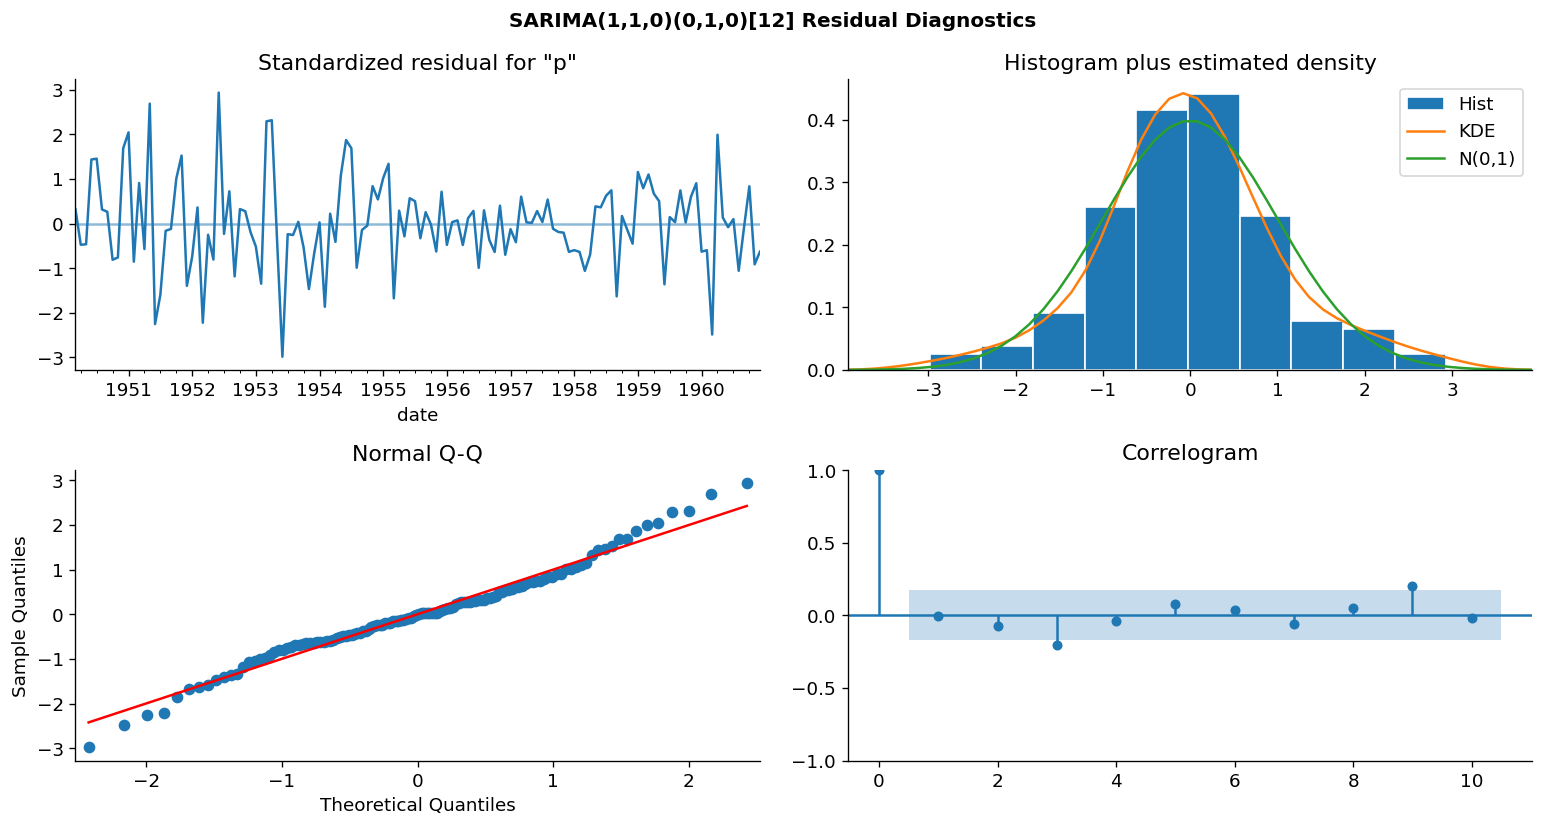

In [ ]:
fig = sarima_model.plot_diagnostics(figsize=(13, 7))
plt.suptitle(f'SARIMA({bp},{bd},{bq})({bP},{bD},{bQ})[12] Residual Diagnostics',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



A grid search was performed over `p, q, P, Q ∈ {0,1,2}`, with `d=1` and `D=1` fixed in advance (both justified earlier through ADF testing and seasonal decomposition). The constraints `enforce_stationarity=False` and `enforce_invertibility=False` were used to improve convergence during estimation.

The AIC-optimal model is **SARIMA(1,1,0)(0,1,0)[12]** (AIC = -445.41). This specification is parsimonious and aligns well with the characteristics of the data:

- The regular difference (`d=1`) removes the long-term trend, while the seasonal difference (`D=1`, period 12) effectively eliminates the strong annual seasonality observed in the log-transformed series.
- After seasonal differencing, additional seasonal AR (`P`) or MA (`Q`) terms do not improve model fit. This indicates that the seasonal autocorrelation structure is largely accounted for by the seasonal differencing itself.
- A single non-seasonal autoregressive term (`p=1`) captures the remaining short-term dependence in the twice-differenced series.

The resulting model is simple yet effective. Residual diagnostics (shown below) confirm that the SARIMA(1,1,0)(0,1,0)[12] specification produces residuals that are close to white noise, with no significant remaining autocorrelation. This represents a substantial improvement over the non-seasonal ARIMA model .

**2.3  Evaluate your SARIMA model using appropriate metrics. Compare its performance to a simple non-seasonal ARIMA model. Discuss why SARIMA is more appropriate for your dataset.**

We evaluate both models on an unseen test set (1958–1960, 36 months), splitting the data at the end of 1957.


Train: 1949-01-01 — 1957-12-01  (108 obs)
Test : 1958-01-01  — 1960-12-01   (36 obs)

Out-of-sample metrics on test set (1958–1960):
----------------------------------------------------------------------
ARIMA(3,1,2)                             RMSE= 102.28  MAE=  76.66  MAPE=15.99%
SARIMA(1,1,0)(0,1,0)[12]                 RMSE=  26.05  MAE=  22.81  MAPE=5.56%


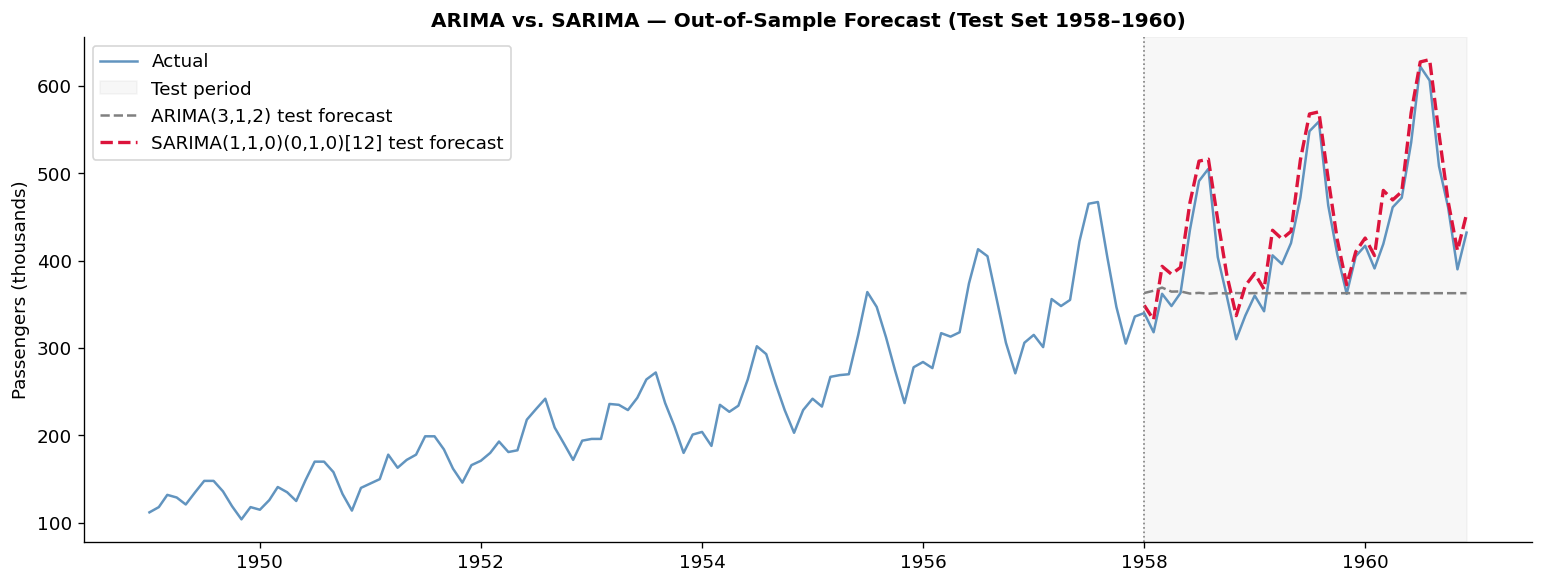

In [ ]:
TRAIN_END = '1957-12-01'
TEST_START = '1958-01-01'

train_ts = ts[:TRAIN_END]
test_ts  = ts[TEST_START:]
print(f"Train: {train_ts.index[0].date()} — {train_ts.index[-1].date()}  ({len(train_ts)} obs)")
print(f"Test : {test_ts.index[0].date()}  — {test_ts.index[-1].date()}   ({len(test_ts)} obs)")

# Re-fit ARIMA on training set only
arima_test_m = ARIMA(np.log(train_ts), order=(best_p, best_d, best_q)).fit()
arima_test_pred = np.exp(arima_test_m.forecast(len(test_ts)))
arima_test_pred.index = test_ts.index

# Re-fit SARIMA on training set only
sarima_test_m = SARIMAX(
    np.log(train_ts),
    order=(bp, bd, bq),
    seasonal_order=(bP, bD, bQ, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
sarima_test_pred = np.exp(sarima_test_m.forecast(len(test_ts)))
sarima_test_pred.index = test_ts.index

def eval_metrics(actual, predicted, name=''):
    a = np.asarray(actual);  p = np.asarray(predicted)
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    mape = np.mean(np.abs((a - p) / a)) * 100
    if name:
        print(f"{name:<40} RMSE={rmse:7.2f}  MAE={mae:7.2f}  MAPE={mape:.2f}%")
    return rmse, mae, mape

print("\nOut-of-sample metrics on test set (1958–1960):")
print("-" * 70)
eval_metrics(test_ts, arima_test_pred,  f'ARIMA({best_p},{best_d},{best_q})')
eval_metrics(test_ts, sarima_test_pred, f'SARIMA({bp},{bd},{bq})({bP},{bD},{bQ})[12]')

# Visualise
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.5, label='Actual', alpha=0.85)
ax.axvspan(test_ts.index[0], test_ts.index[-1], alpha=0.06, color='gray', label='Test period')
ax.plot(arima_test_pred.index, arima_test_pred.values, color='gray', linewidth=1.5,
        linestyle='--', label=f'ARIMA({best_p},{best_d},{best_q}) test forecast')
ax.plot(sarima_test_pred.index, sarima_test_pred.values, color='crimson', linewidth=2,
        linestyle='--', label=f'SARIMA({bp},{bd},{bq})({bP},{bD},{bQ})[12] test forecast')
ax.axvline(test_ts.index[0], color='gray', linestyle=':', linewidth=1)
ax.set_title('ARIMA vs. SARIMA — Out-of-Sample Forecast (Test Set 1958–1960)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()



To provide an honest evaluation, both models were re-estimated on the training set (1949–1957) and evaluated on the unseen test set (1958–1960).

The performance difference is substantial:

- **ARIMA(3,1,2)** produces a nearly flat forecast around 360 thousand passengers, completely failing to capture the seasonal pattern. This results in large systematic errors, particularly during summer peaks (underestimation) and winter troughs (overestimation), leading to a MAPE of 15.99%.

- **SARIMA(1,1,0)(0,1,0)[12]** follows both the trend and the seasonal cycle much more closely. Although it slightly overestimates some peaks in 1959 and 1960, it achieves a MAPE of only 5.56% - roughly three times better than the non-seasonal ARIMA.

These results demonstrate that seasonality is the dominant predictable component in this dataset.

**2.4 Generate forecasts for a reasonable future period using your SARIMA model. Plot the forecasts along with prediction intervals. Discuss the uncertainty in your forecasts and how it changes over the forecast horizon.**

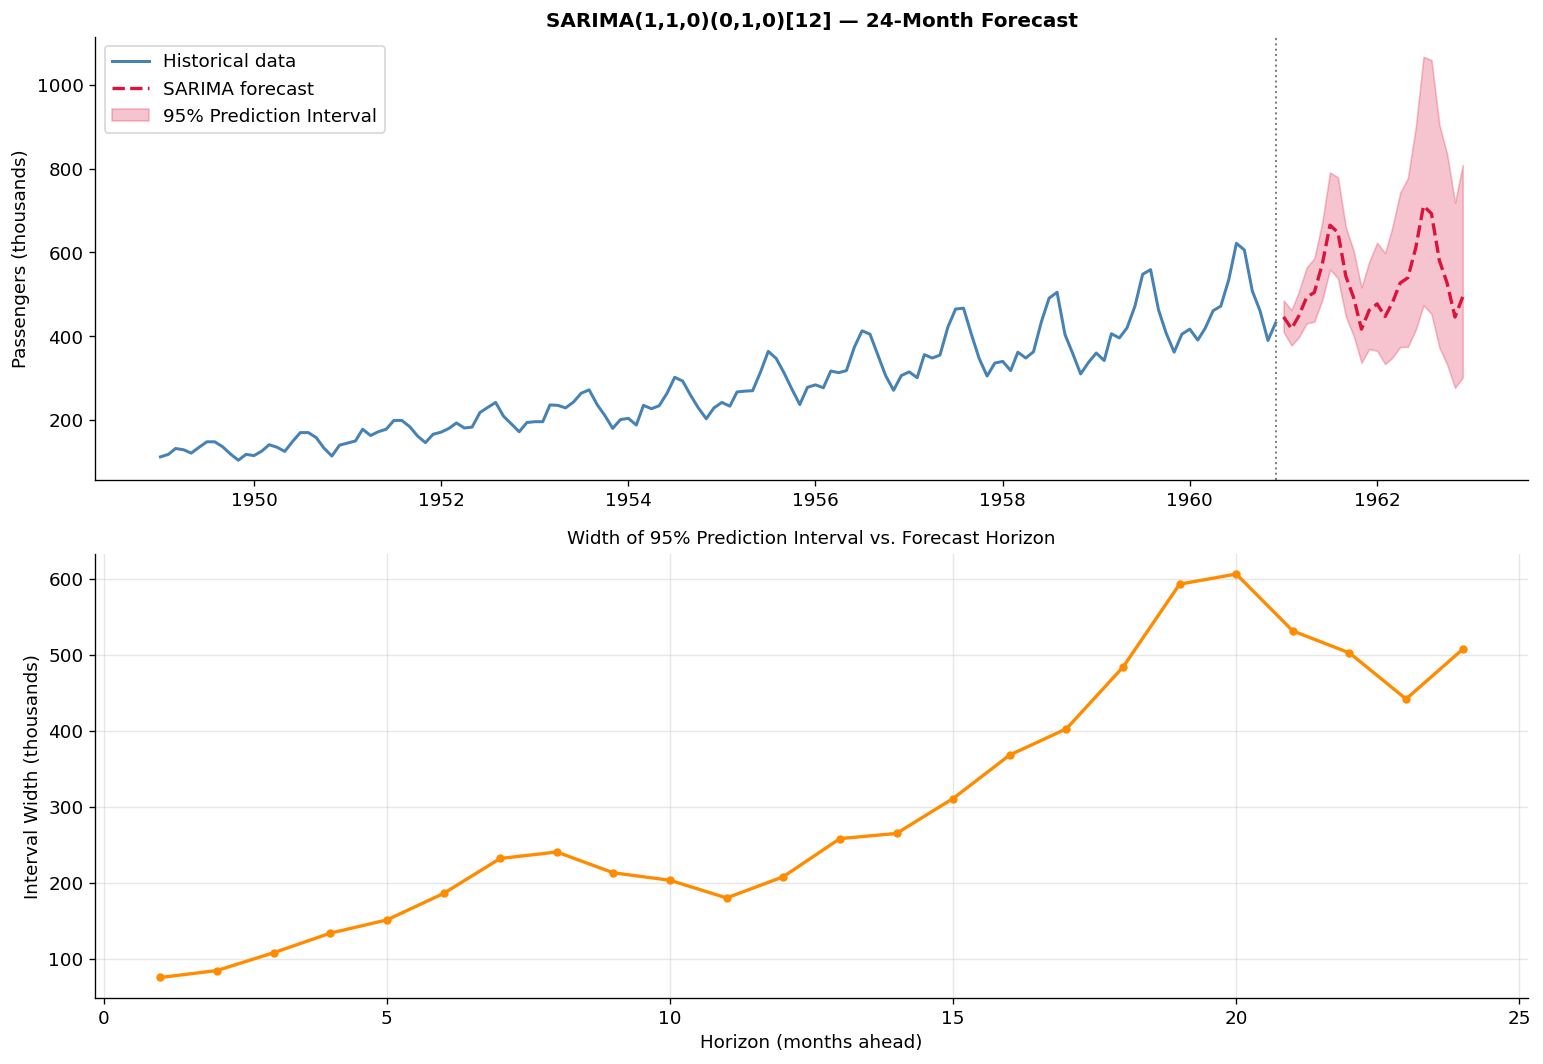

24-month SARIMA forecast:
            Forecast  Lower 95%  Upper 95%
1961-01-01     446.0      410.0      486.0
1961-02-01     418.0      378.0      462.0
1961-03-01     448.0      397.0      505.0
1961-04-01     493.0      431.0      564.0
1961-05-01     505.0      435.0      586.0
1961-06-01     572.0      487.0      673.0
1961-07-01     665.0      559.0      791.0
1961-08-01     648.0      539.0      779.0
1961-09-01     543.0      447.0      660.0
1961-10-01     493.0      402.0      605.0
1961-11-01     417.0      337.0      517.0
1961-12-01     462.0      370.0      577.0
1962-01-01     477.0      365.0      623.0
1962-02-01     447.0      334.0      599.0
1962-03-01     479.0      348.0      659.0
1962-04-01     527.0      374.0      743.0
1962-05-01     540.0      375.0      778.0
1962-06-01     612.0      416.0      900.0
1962-07-01     711.0      474.0     1067.0
1962-08-01     693.0      453.0     1060.0
1962-09-01     581.0      373.0      905.0
1962-10-01     527.0      33

In [ ]:
n_fc2 = 24
fc_s       = sarima_model.get_forecast(steps=n_fc2)
fc_s_mean  = np.exp(fc_s.predicted_mean)
fc_s_ci    = fc_s.conf_int(alpha=0.05)
fc_s_lower = np.exp(fc_s_ci.iloc[:, 0])
fc_s_upper = np.exp(fc_s_ci.iloc[:, 1])

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

axes[0].plot(ts.index, ts.values, color='steelblue', linewidth=1.8, label='Historical data')
axes[0].plot(fc_s_mean.index, fc_s_mean.values, color='crimson', linewidth=2,
             linestyle='--', label='SARIMA forecast')
axes[0].fill_between(fc_s_mean.index, fc_s_lower.values, fc_s_upper.values,
                     alpha=0.25, color='crimson', label='95% Prediction Interval')
axes[0].axvline(ts.index[-1], color='gray', linestyle=':', linewidth=1.2)
axes[0].set_title(f'SARIMA({bp},{bd},{bq})({bP},{bD},{bQ})[12] — 24-Month Forecast',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Passengers (thousands)')
axes[0].legend()

iw = fc_s_upper.values - fc_s_lower.values
axes[1].plot(range(1, n_fc2 + 1), iw, color='darkorange', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Width of 95% Prediction Interval vs. Forecast Horizon', fontsize=11)
axes[1].set_xlabel('Horizon (months ahead)')
axes[1].set_ylabel('Interval Width (thousands)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("24-month SARIMA forecast:")
print(pd.DataFrame({
    'Forecast': fc_s_mean.round(0),
    'Lower 95%': fc_s_lower.round(0),
    'Upper 95%': fc_s_upper.round(0)
}).to_string())



The  forecast captures both major components of the series:

- **Trend continuation**: The forecast shows a steady upward trajectory into 1961–1962, consistent with the historical growth rate.
- **Seasonal cycle**: Summer peaks and winter troughs are clearly reproduced, representing a major improvement over the non-seasonal ARIMA model, which produced an almost flat forecast.


The lower panel shows that the width of the 95% prediction intervals increases with the forecast horizon, as expected. Each additional step accumulates innovation variance, leading to greater uncertainty further into the future. The growth is not perfectly linear - there is a slight seasonal oscillation, with intervals tending to be narrower around seasonal peaks (where the model is more confident in the recurring pattern).

**Asymmetric intervals**: Because the model was estimated on the log scale and then back-transformed, the prediction intervals are asymmetric (wider on the upper side). This is statistically appropriate for a multiplicative process: positive shocks can compound, while the series cannot fall below zero.



## Problem 3: Machine Learning and Prophet for Time Series


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load raw hourly data
df_raw = pd.read_csv('/content/drive/MyDrive/PJME_hourly.csv')
df_raw['Datetime'] = pd.to_datetime(df_raw['Datetime'])
df_raw = df_raw.sort_values('Datetime').set_index('Datetime')
ts_hourly = df_raw['PJME_MW']

print(f"Raw hourly data: {len(ts_hourly):,} observations")
print(f"Date range: {ts_hourly.index[0]}  —  {ts_hourly.index[-1]}")
print(f"Min: {ts_hourly.min():,.0f} MW   Max: {ts_hourly.max():,.0f} MW")

expected = pd.date_range(ts_hourly.index[0], ts_hourly.index[-1], freq='h')
missing = expected.difference(ts_hourly.index)
print(f"Missing hourly timestamps: {len(missing)}")

# Aggregate to weekly mean
ts_weekly = ts_hourly.resample('W').mean().dropna()
print(f"\nWeekly aggregated: {len(ts_weekly)} observations")
print(f"Date range: {ts_weekly.index[0].date()} — {ts_weekly.index[-1].date()}")
print(f"Mean: {ts_weekly.mean():.0f} MW   Std: {ts_weekly.std():.0f} MW")


Raw hourly data: 145,366 observations
Date range: 2002-01-01 01:00:00  —  2018-08-03 00:00:00
Min: 14,544 MW   Max: 62,009 MW
Missing hourly timestamps: 30

Weekly aggregated: 866 observations
Date range: 2002-01-06 — 2018-08-05
Mean: 32082 MW   Std: 3982 MW


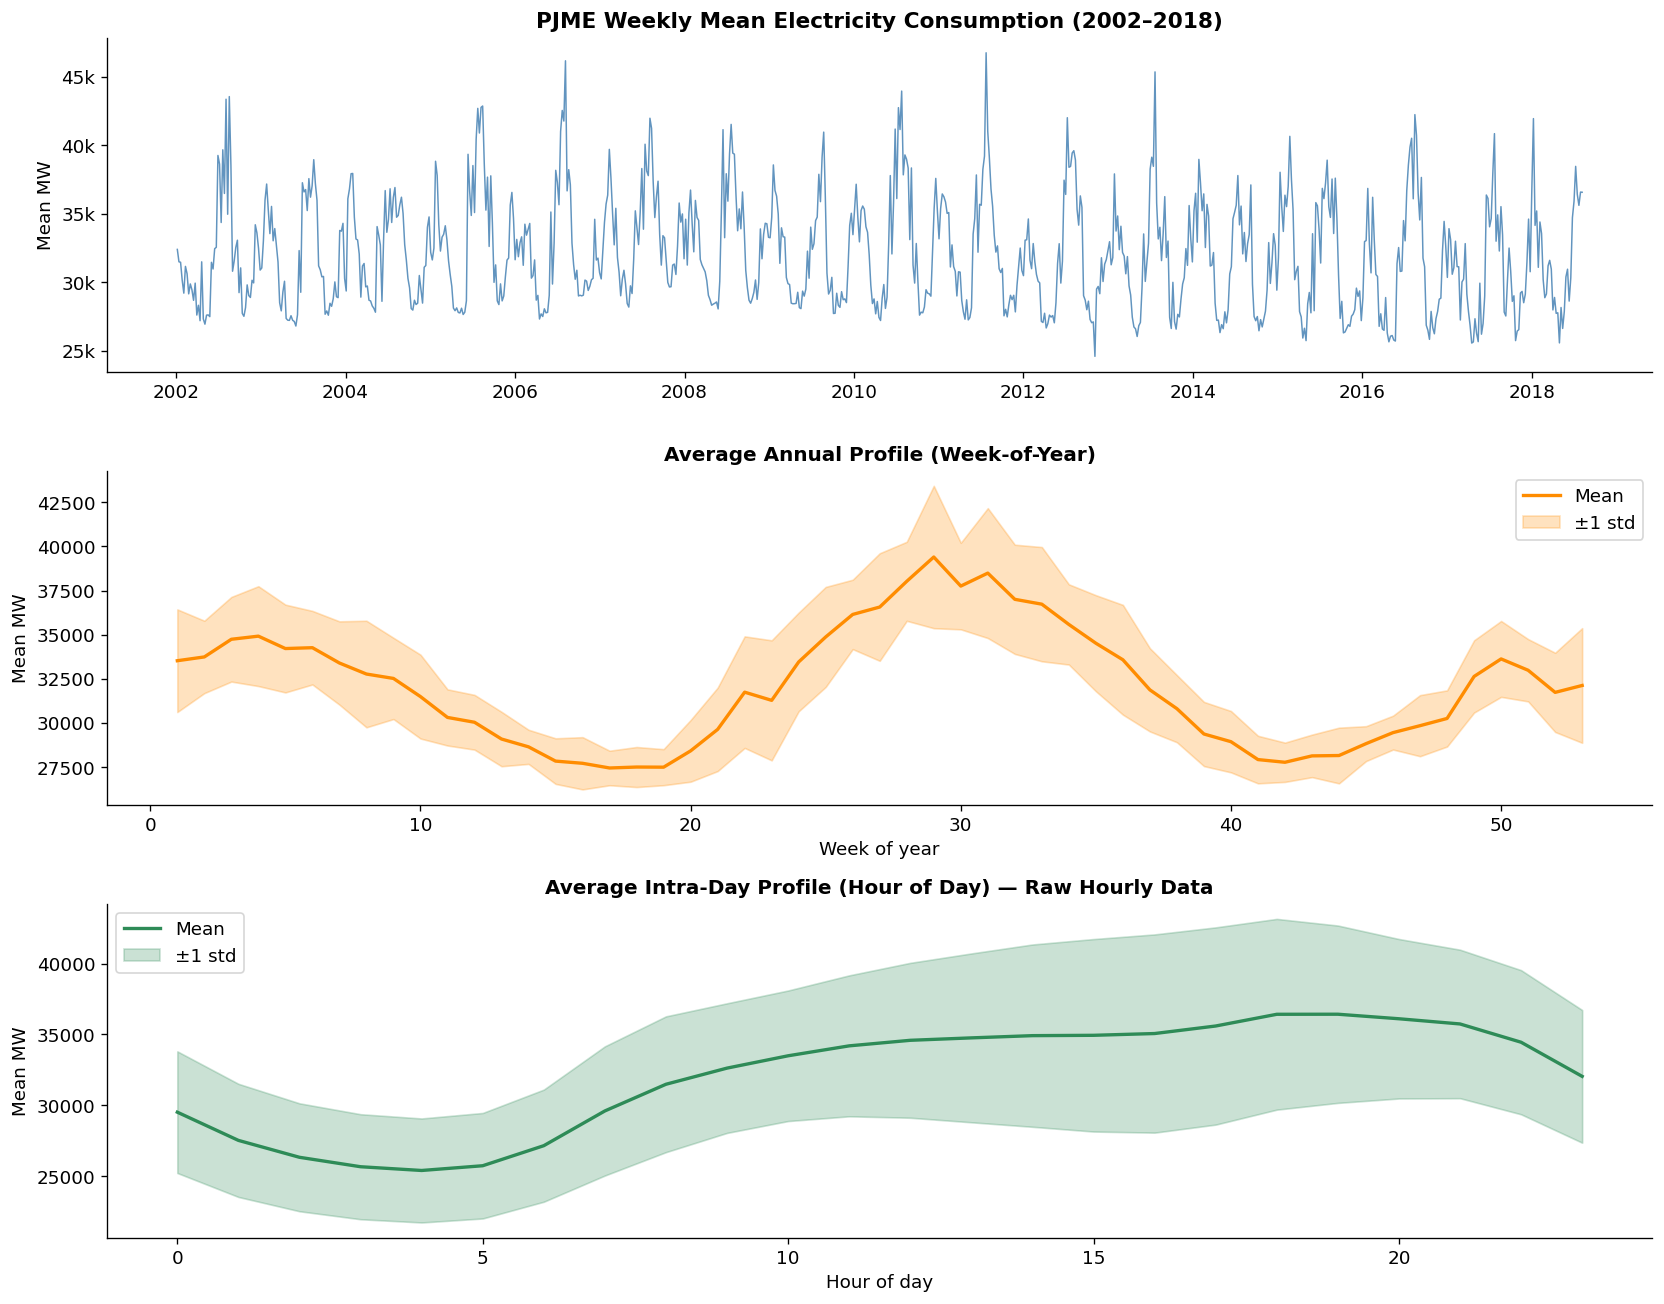

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Full weekly series
axes[0].plot(ts_weekly.index, ts_weekly.values, color='steelblue', linewidth=0.9, alpha=0.85)
axes[0].set_title('PJME Weekly Mean Electricity Consumption (2002–2018)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean MW')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Average week-of-year profile (annual seasonality)
ts_weekly_df = ts_weekly.to_frame('MW')
ts_weekly_df['week'] = ts_weekly_df.index.isocalendar().week.astype(int)
weekly_profile = ts_weekly_df.groupby('week')['MW'].agg(['mean','std'])
axes[1].plot(weekly_profile.index, weekly_profile['mean'],
             color='darkorange', linewidth=2, label='Mean')
axes[1].fill_between(weekly_profile.index,
                     weekly_profile['mean'] - weekly_profile['std'],
                     weekly_profile['mean'] + weekly_profile['std'],
                     alpha=0.25, color='darkorange', label='±1 std')
axes[1].set_title('Average Annual Profile (Week-of-Year)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Week of year')
axes[1].set_ylabel('Mean MW')
axes[1].legend()

# Hourly profile (intra-day pattern, raw data)
hourly_profile = ts_hourly.groupby(ts_hourly.index.hour).agg(['mean','std'])
axes[2].plot(hourly_profile.index, hourly_profile['mean'],
             color='seagreen', linewidth=2, label='Mean')
axes[2].fill_between(hourly_profile.index,
                     hourly_profile['mean'] - hourly_profile['std'],
                     hourly_profile['mean'] + hourly_profile['std'],
                     alpha=0.25, color='seagreen', label='±1 std')
axes[2].set_title('Average Intra-Day Profile (Hour of Day) — Raw Hourly Data',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hour of day')
axes[2].set_ylabel('Mean MW')
axes[2].legend()

plt.tight_layout()
plt.show()



**3.1 Select a time series dataset that would benefit from advanced forecasting techniques. Prepare the data for machine learning approaches by creating appropriate features. Consider including:**
   - **Lag features (previous periods)**
   - **Time-based features (day of week, month of year, etc.)**
   - **Holiday indicators (if relevant)**
   - **Any other features you think might be useful**


In [ ]:
def build_features(ts: pd.Series) -> pd.DataFrame:
    """
    Build a supervised-learning feature matrix from a weekly time series.
    All features are constructed with appropriate shifts to prevent data leakage.
    """
    df_f = pd.DataFrame({'y': ts})

    # ── Lag features ─────────────────────────────────────────────────────────
    # Short-term lags: capture recent autocorrelation
    for lag in [1, 2, 3, 4]:
        df_f[f'lag_{lag}w'] = df_f['y'].shift(lag)

    # Seasonal lags: same week last year, 2 years ago
    for lag in [52, 53, 104]:
        df_f[f'lag_{lag}w'] = df_f['y'].shift(lag)

    # Rolling statistics
    # Short-term trend (1 month)
    df_f['roll_mean_4w']  = df_f['y'].shift(1).rolling(4).mean()
    # Quarterly mean (captures season-within-season)
    df_f['roll_mean_13w'] = df_f['y'].shift(1).rolling(13).mean()
    # Annual moving average (trend proxy)
    df_f['roll_mean_52w'] = df_f['y'].shift(1).rolling(52).mean()
    # Short-term volatility
    df_f['roll_std_4w']   = df_f['y'].shift(1).rolling(4).std()

    #  Cyclical calendar encoding
    # Encode week-of-year cyclically so week 52 and week 1 are adjacent
    week_num = ts.index.isocalendar().week.astype(int)
    df_f['week_sin'] = np.sin(2 * np.pi * week_num / 52)
    df_f['week_cos'] = np.cos(2 * np.pi * week_num / 52)

    #  Calendar scalars
    df_f['week']    = week_num.values
    df_f['month']   = ts.index.month
    df_f['quarter'] = ts.index.quarter

    #  Trend index
    # Integer counter; allows RF to learn the mild level drift over years
    df_f['trend'] = np.arange(len(ts))

    return df_f.dropna()

features_df  = build_features(ts_weekly)
feature_cols = [c for c in features_df.columns if c != 'y']

print(f"Feature matrix: {features_df.shape[0]} rows × {len(feature_cols)} features")
print(f"Effective start date (after lag burn-in): {features_df.index[0].date()}")
print(f"\nFeature list:")
for col in feature_cols:
    print(f"  {col}")


Feature matrix: 762 rows × 17 features
Effective start date (after lag burn-in): 2004-01-04

Feature list:
  lag_1w
  lag_2w
  lag_3w
  lag_4w
  lag_52w
  lag_53w
  lag_104w
  roll_mean_4w
  roll_mean_13w
  roll_mean_52w
  roll_std_4w
  week_sin
  week_cos
  week
  month
  quarter
  trend



The following groups of features were created:

- **Lag features**: Short-term lags (`lag_1w`–`lag_4w`) capture recent weekly autocorrelation, while seasonal lags (`lag_52w`, `lag_53w`, `lag_104w`) allow the model to learn the consumption level in the same week of previous years.
- **Rolling statistics**: Moving averages over 4, 13, and 52 weeks encode short-term momentum, quarterly patterns, and the annual baseline level respectively. Rolling standard deviation over 4 weeks captures local volatility (e.g., unusual weather events).
- **Cyclical week encoding** (`week_sin`, `week_cos`): This ensures that the transition from week 52 to week 1 is treated as continuous, which is essential for modelling annual seasonality correctly.
- **Calendar features** (`week`, `month`, `quarter`): Provide additional discrete seasonal information at different temporal resolutions.
- **Trend index** (`trend`): Even though the series has only a mild downward drift after 2008, this feature allows the model to capture any slow level changes over the 16-year period.


- No logarithmic transformation was applied, as the series exhibits additive seasonality and stable variance.
- The feature set combines short-term dynamics, annual seasonal memory, and a weak trend component, which together provide the model with sufficient information to capture the complex U-shaped annual seasonality observed in the data.

**3.2 Split the data into training and testing sets. Train the following models on the training data:**
   - **A SARIMA model**
   - **A machine learning model (Random Forest, XGBoost, or another algorithm** **of your choice) using your engineered features**
   - **A Facebook Prophet model with appropriate seasonality and holiday effects**

In [ ]:
N_TEST = 52
train_ts = ts_weekly[:-N_TEST]
test_ts  = ts_weekly[-N_TEST:]

print(f"Training set : {train_ts.index[0].date()} — {train_ts.index[-1].date()}  ({len(train_ts)} weeks)")
print(f"Test set     : {test_ts.index[0].date()}  — {test_ts.index[-1].date()}   ({len(test_ts)} weeks)")
print(f"Train share  : {len(train_ts)/len(ts_weekly)*100:.1f}%")

from statsmodels.tsa.stattools import adfuller

print("ADF Test on Weekly PJME Series (Training Set)")
result = adfuller(train_ts, autolag='AIC')

print(f"Test Statistic : {result[0]:.4f}")
print(f"p-value        : {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"  {key}% : {value:.4f}")

if result[1] < 0.05:
    print("\n→ The series is stationary at 5% significance level (d = 0)")
else:
    print("\n→ The series is non-stationary (consider d = 1)")

Training set : 2002-01-06 — 2017-08-06  (814 weeks)
Test set     : 2017-08-13  — 2018-08-05   (52 weeks)
Train share  : 94.0%
ADF Test on Weekly PJME Series (Training Set)
Test Statistic : -12.4563
p-value        : 0.0000
Critical Values:
  1%% : -3.4385
  5%% : -2.8652
  10%% : -2.5687

→ The series is stationary at 5% significance level (d = 0)


In [ ]:
auto_model = auto_arima(
    train_ts,
    seasonal=True,
    m=52,
    d=0,
    D=1,

    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,

    information_criterion='aic',
    stepwise=True,
    n_jobs=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    maxiter=50
)

print(auto_model.summary())

bp, bd, bq = auto_model.order
bP, bD, bQ, bs = auto_model.seasonal_order

print(f"\n Best model: SARIMA({bp},{bd},{bq})({bP},{bD},{bQ})[{bs}]")
print(f"   AIC = {auto_model.aic():.2f}")

Training set : 2002-01-06 — 2017-08-06  (814 weeks)
Test set     : 2017-08-13  — 2018-08-05   (52 weeks)
Train share  : 94.0%
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[52] intercept   : AIC=14068.494, Time=252.05 sec
 ARIMA(0,0,0)(0,1,0)[52] intercept   : AIC=14314.880, Time=2.77 sec
 ARIMA(1,0,0)(1,1,0)[52] intercept   : AIC=14194.513, Time=30.92 sec
 ARIMA(0,0,1)(0,1,1)[52] intercept   : AIC=14216.679, Time=24.70 sec
 ARIMA(0,0,0)(0,1,0)[52]             : AIC=14312.994, Time=1.35 sec
 ARIMA(2,0,2)(0,1,1)[52] intercept   : AIC=inf, Time=230.35 sec
 ARIMA(2,0,2)(1,1,0)[52] intercept   : AIC=14113.069, Time=208.68 sec
 ARIMA(2,0,2)(0,1,0)[52] intercept   : AIC=14223.203, Time=18.66 sec
 ARIMA(1,0,2)(1,1,1)[52] intercept   : AIC=inf, Time=195.15 sec
 ARIMA(2,0,1)(1,1,1)[52] intercept   : AIC=inf, Time=201.00 sec
 ARIMA(1,0,1)(1,1,1)[52] intercept   : AIC=inf, Time=174.10 sec
 ARIMA(2,0,2)(1,1,1)[52]             : AIC=inf, Time=226.49 sec

Best model:  ARIMA(2,0,2)(1

In [ ]:
# Fit best SARIMA on training set
sarima_model = SARIMAX(
    train_ts,
    order=(bp, bd, bq),
    seasonal_order=(bP, bD, bQ, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
print(sarima_model.summary())


                                      SARIMAX Results                                       
Dep. Variable:                              PJME_MW   No. Observations:                  814
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 52)   Log Likelihood               -6473.102
Date:                              Fri, 12 Jun 2026   AIC                          12960.203
Time:                                      05:16:01   BIC                          12992.131
Sample:                                  01-06-2002   HQIC                         12972.539
                                       - 08-06-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5381      0.217      7.080      0.000       1.112       1.964
ar.L2         -0.55

The Augmented Dickey-Fuller test confirmed that the weekly series is stationary, so no regular differencing was applied (d = 0). One seasonal difference (D = 1, s = 52) was used to remove annual seasonality. No log transformation was applied due to additive seasonality.
auto_arima with a stepwise search identified SARIMA(2,0,2)(1,1,1)[52] as the best model by AIC. However, the model has several limitations: the ma.L2 coefficient is insignificant, residual autocorrelation remains at lag 1 (Ljung-Box p = 0.03), residuals are non-normal, and a near-singular covariance matrix warning was issued. The model was nevertheless retained, as it achieved the lowest AIC among all converged specifications.

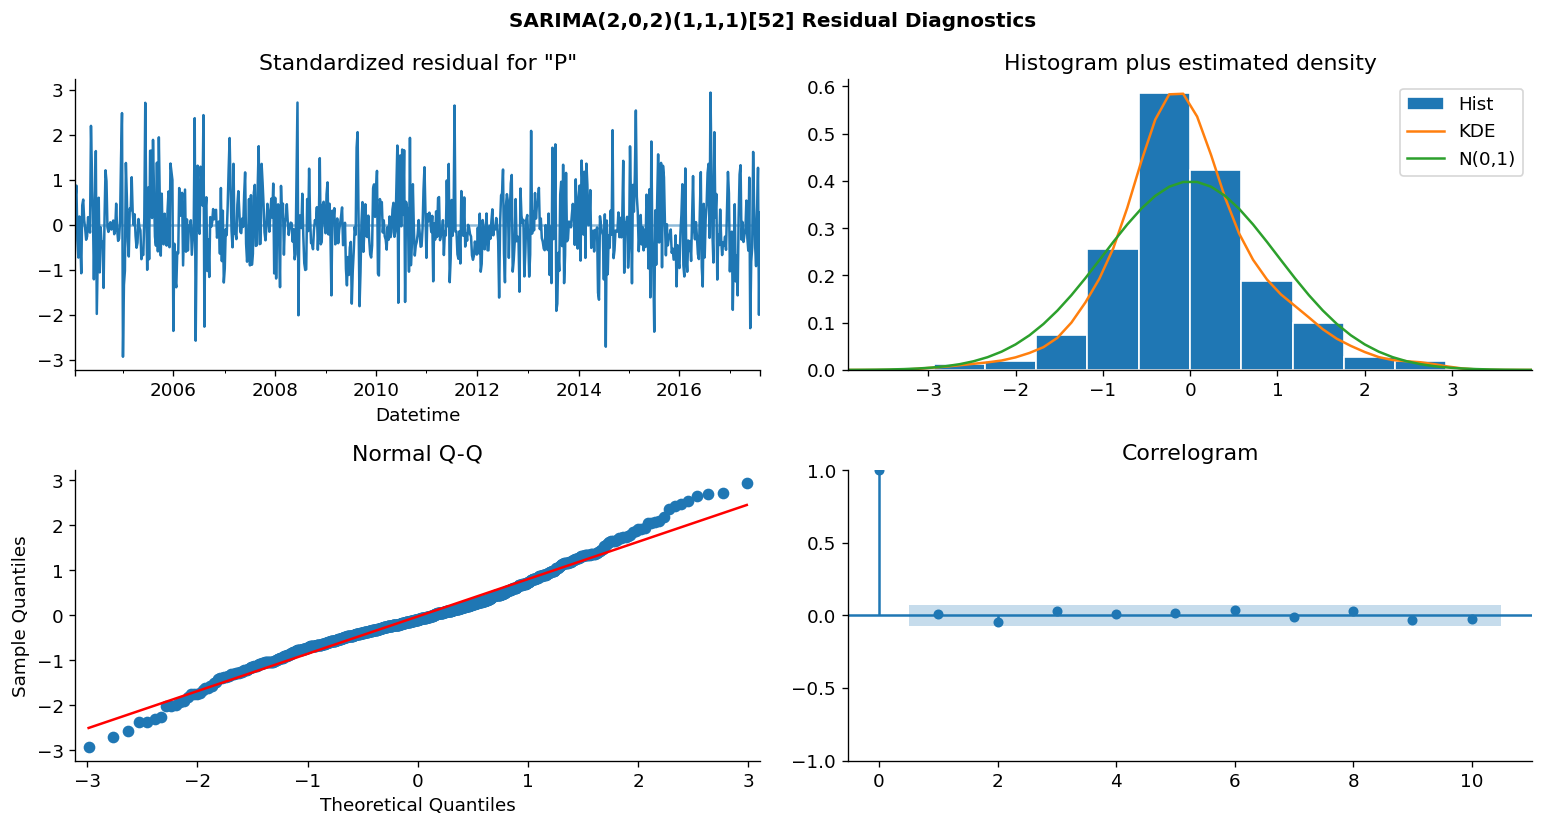

In [ ]:
fig = sarima_model.plot_diagnostics(figsize=(13, 7))
plt.suptitle(f'SARIMA({bp},{bd},{bq})({bP},{bD},{bQ})[52] Residual Diagnostics',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Random Forest
train_feat = features_df.loc[features_df.index <= train_ts.index[-1]]
test_feat  = features_df.loc[features_df.index >= test_ts.index[0]]

X_train = train_feat[feature_cols];  y_train = train_feat['y']
X_test  = test_feat[feature_cols];   y_test  = test_feat['y']

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = pd.Series(rf_model.predict(X_test), index=test_feat.index)

print(f"RF training samples: {len(X_train)}")
print(f"RF test samples    : {len(X_test)}")



RF training samples: 710
RF test samples    : 52


In [ ]:
# Prophet
prophet_train = train_ts.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,    # aggregated to weekly -> no sub-weekly pattern
    daily_seasonality=False,
    seasonality_mode='additive', # additive: stable variance
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    interval_width=0.95
)
# US federal holidays affect electricity demand
prophet_model.add_country_holidays(country_name='US')
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=N_TEST, freq='W')
prophet_fc   = prophet_model.predict(future)
prophet_pred = pd.Series(
    prophet_fc.set_index('ds')['yhat'].loc[test_ts.index].values,
    index=test_ts.index
)
prophet_lo = pd.Series(
    prophet_fc.set_index('ds')['yhat_lower'].loc[test_ts.index].values,
    index=test_ts.index
)
prophet_hi = pd.Series(
    prophet_fc.set_index('ds')['yhat_upper'].loc[test_ts.index].values,
    index=test_ts.index
)



**3.3 Evaluate all three models on the test set using appropriate metrics (RMSE, MAE, MAPE). Present your results in a table and provide visualizations comparing the forecasts from each model against the actual values.**

**3.4 Discuss the strengths and weaknesses of each approach**

In [ ]:
def eval_metrics(actual, predicted, name=''):
    a = np.asarray(actual).flatten()
    p = np.asarray(predicted).flatten()
    # align lengths
    n = min(len(a), len(p))
    a, p = a[:n], p[:n]
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    mape = np.mean(np.abs((a - p) / a)) * 100
    if name:
        print(f"{name:<45} RMSE={rmse:7.1f}  MAE={mae:7.1f}  MAPE={mape:.2f}%")
    return rmse, mae, mape

# Align SARIMA predictions to test index
sarima_pred = sarima_model.forecast(N_TEST)
sarima_pred.index = test_ts.index

models_preds = {
    f'SARIMA({bp},{bd},{bq})({bP},{bD},{bQ})[52]': sarima_pred,
    'Random Forest':                                rf_pred,
    'Prophet (additive + US holidays)':             prophet_pred,
}

eval_rows = []
print("=" * 72)
print(f"TEST SET METRICS  ({test_ts.index[0].date()} — {test_ts.index[-1].date()})")
print("=" * 72)
print(f"{'MODEL':<45} {'RMSE':>7} {'MAE':>7} {'MAPE':>7}")
print("-" * 72)
for name, pred in models_preds.items():
    rmse, mae, mape = eval_metrics(test_ts.values, pred.values, name)
    eval_rows.append({'Model': name,
                      'RMSE (MW)': round(rmse, 0),
                      'MAE (MW)':  round(mae, 0),
                      'MAPE (%)':  round(mape, 2)})
print("=" * 72)

eval_df = pd.DataFrame(eval_rows).sort_values('RMSE (MW)')
print("\nSorted by RMSE:")
print(eval_df.to_string(index=False))


TEST SET METRICS  (2017-08-13 — 2018-08-05)
MODEL                                            RMSE     MAE    MAPE
------------------------------------------------------------------------
SARIMA(2,0,2)(1,1,1)[52]                      RMSE= 2509.4  MAE= 1877.2  MAPE=5.99%
Random Forest                                 RMSE= 2302.2  MAE= 1683.6  MAPE=5.33%
Prophet (additive + US holidays)              RMSE= 2576.4  MAE= 1885.5  MAPE=5.92%

Sorted by RMSE:
                           Model  RMSE (MW)  MAE (MW)  MAPE (%)
                   Random Forest     2302.0    1684.0      5.33
        SARIMA(2,0,2)(1,1,1)[52]     2509.0    1877.0      5.99
Prophet (additive + US holidays)     2576.0    1885.0      5.92


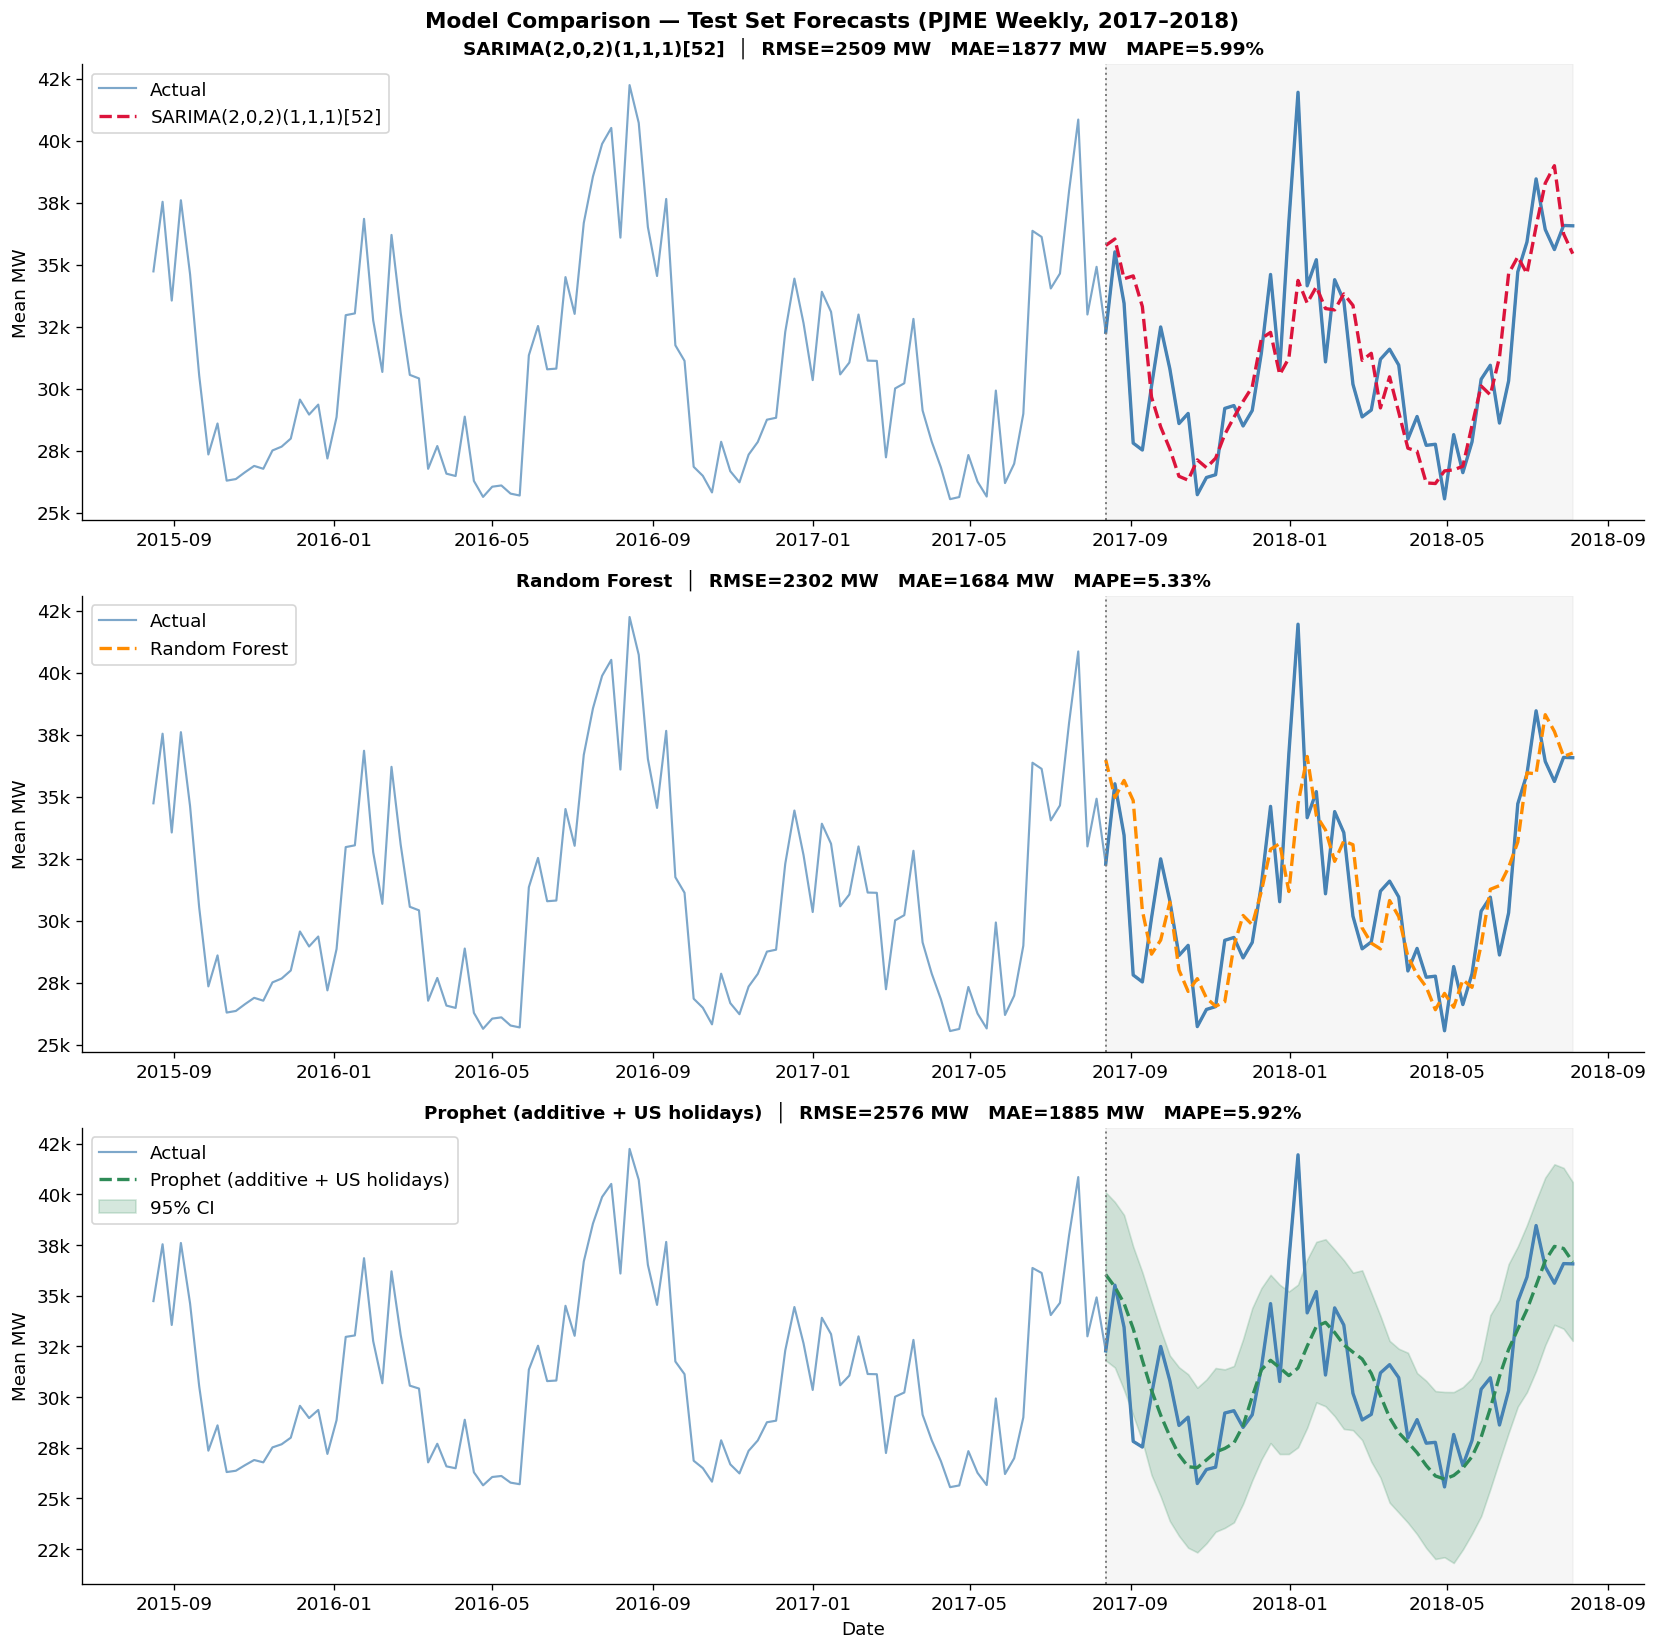

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
line_colors = ['crimson', 'darkorange', 'seagreen']

for i, (name, pred) in enumerate(models_preds.items()):
    ax = axes[i]
    # Show last 2 years of training + full test
    plot_start = train_ts.index[-104]
    hist_plot = ts_weekly[plot_start:]

    ax.plot(hist_plot.index, hist_plot.values,
            color='steelblue', linewidth=1.3, label='Actual', alpha=0.7)
    ax.axvspan(test_ts.index[0], test_ts.index[-1], alpha=0.07, color='gray')
    ax.plot(test_ts.index, test_ts.values,
            color='steelblue', linewidth=2)
    ax.plot(pred.index, pred.values[:len(pred.index)],
            color=line_colors[i], linewidth=2, linestyle='--', label=name)

    # Add Prophet CI
    if 'Prophet' in name:
        ax.fill_between(prophet_lo.index, prophet_lo.values, prophet_hi.values,
                        alpha=0.2, color=line_colors[i], label='95% CI')

    rmse, mae, mape = eval_metrics(
        test_ts.values,
        pred.values[:len(test_ts)]
    )
    ax.set_title(f'{name}  │  RMSE={rmse:.0f} MW   MAE={mae:.0f} MW   MAPE={mape:.2f}%',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean MW')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.axvline(test_ts.index[0], color='gray', linestyle=':', linewidth=1.2)
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Date')
plt.suptitle('Model Comparison — Test Set Forecasts (PJME Weekly, 2017–2018)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()





All three models were evaluated on the held-out test set consisting of the last 52 weeks (August 2017 – August 2018).

**Test Set Performance (2017-08-13 — 2018-08-05)**

| Model                              | RMSE (MW) | MAE (MW) | MAPE (%) |
|------------------------------------|-----------|----------|----------|
| **Random Forest**                  | **2302**  | **1684** | **5.33** |
| SARIMA(2,0,2)(1,1,1)[52]           | 2509      | 1877     | 5.99     |
| Prophet (additive + US holidays)   | 2576      | 1885     | 5.92     |


On this dataset, the **Random Forest** model achieved the best out-of-sample performance across all metrics.

Several factors explain why Random Forest performed well on the PJME weekly series:

- The series is approximately stationary, which removes the main limitation of tree-based models — their inability to extrapolate trends.
- The dataset contains rich annual seasonal patterns. The inclusion of lag features at 52 and 104 weeks, combined with rolling statistics and cyclical week encoding, allowed the model to effectively capture within-year dynamics.
- Random Forest can flexibly model non-linear relationships and interactions between features without strong parametric assumptions.

**SARIMA(2,0,2)(1,1,1)[52]** performed worse than expected. Although the model captures the overall annual seasonality, it struggles with short-term fluctuations and transient anomalies (such as unusual weather events). Additionally, the model exhibited several diagnostic issues, including insignificant coefficients and a near-singular covariance matrix, which may have affected its predictive performance.

**Prophet** produced results comparable to SARIMA. While it handled the annual seasonality reasonably well and benefited from the inclusion of US holidays, its flexible piecewise-linear trend component introduced unnecessary complexity for a series with relatively stable levels. As a result, Prophet slightly underperformed compared to both Random Forest and SARIMA.


On datasets with stable levels and complex seasonal structures,machine learning models can outperform traditional SARIMA specifications. In this case, the combination of lag features, rolling statistics, and cyclical encoding enabled Random Forest to better capture the underlying patterns than parametric time series models.



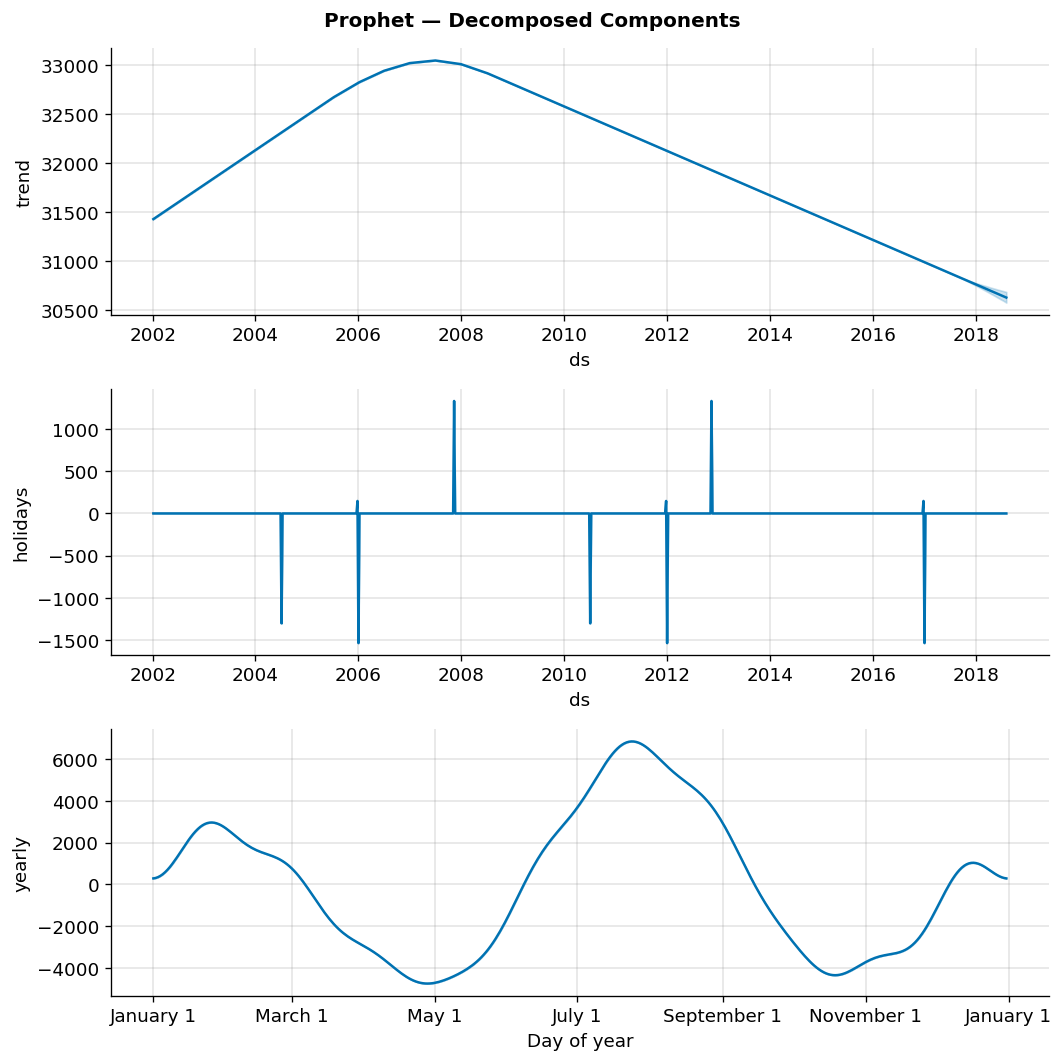

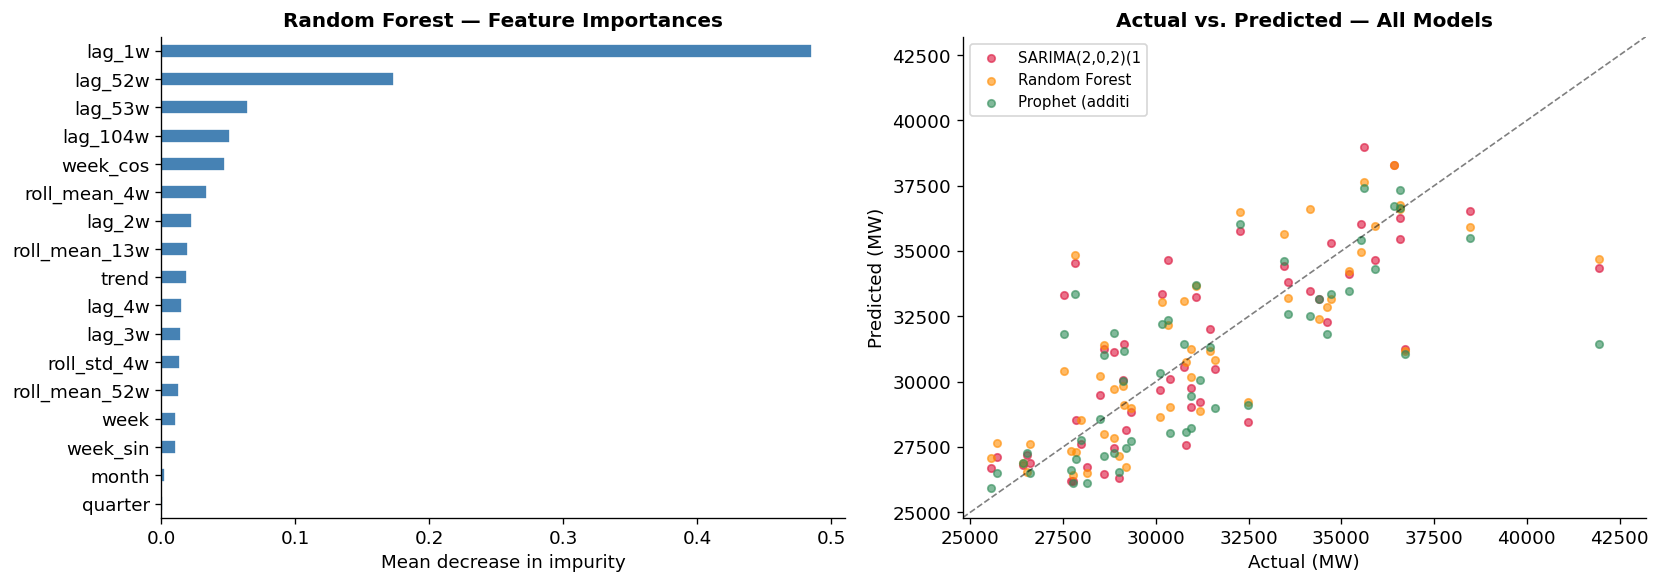


Top-5 most important features:
lag_1w      0.485683
lag_52w     0.173516
lag_53w     0.064980
lag_104w    0.051005
week_cos    0.047748


In [ ]:
# Feature importance
importances = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

importances.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest — Feature Importances', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean decrease in impurity')

# Prophet components
fig2 = prophet_model.plot_components(prophet_fc)
fig2.suptitle('Prophet — Decomposed Components', fontsize=12, fontweight='bold')
fig2.tight_layout()

plt.figure(fig.number)
# Scatter: actual vs. predicted for all models
ax2 = axes[1]
for name, pred, col in zip(models_preds.keys(), models_preds.values(), line_colors):
    n = min(len(test_ts), len(pred))
    ax2.scatter(test_ts.values[:n], pred.values[:n],
                alpha=0.6, s=20, color=col, label=name[:15])
lim = (min(test_ts.min(), min(p.min() for p in models_preds.values())) * 0.97,
       max(test_ts.max(), max(p.max() for p in models_preds.values())) * 1.03)
ax2.plot(lim, lim, 'k--', linewidth=1, alpha=0.5)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel('Actual (MW)'); ax2.set_ylabel('Predicted (MW)')
ax2.set_title('Actual vs. Predicted — All Models', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("\nTop-5 most important features:")
print(importances.tail(5).sort_values(ascending=False).to_string())


Feature importance analysis shows that lag_1w and lag_52w are the most influential predictors, highlighting the importance of both recent values and annual seasonal memory. Cyclical week encodings also contribute meaningfully, while the trend feature has low importance, consistent with the relatively stable level of the series.
Prophet decomposition reveals a mild downward trend after 2008 and a U-shaped annual seasonality with winter and summer peaks. The scatter plot of actual vs. predicted values indicates that Random Forest produces more accurate forecasts, with predictions more tightly clustered around the diagonal. Larger errors across all models occur primarily during periods of extreme demand.


## Problem 4: Forecasting Horizon Challenges

**4.1 Implement and compare two forecasting approaches:**
   **- Direct one-step ahead forecasting: Predict each point in the test set individually using only actual historical values.**
   **- Recursive multi-step forecasting: Predict one step ahead, then use that prediction as an input to predict the next step, and so on.**

   **Generate forecasts for the entire test period using both approaches. Plot and compare the results.**



We use the **Random Forest** model (best performer in Problem 3) to compare the two forecasting approaches on the PJME weekly test set. RF is chosen because: (1) it achieves the lowest error, (2) recursive multi-step forecasting is straightforward to implement by iteratively extending the feature matrix, and (3) bootstrap-based confidence intervals are natural for ensemble models.




In [ ]:
# Rolling One-Step-Ahead

pred_os  = []
n_trees  = 300

for i in range(N_TEST):
    # History: all actual values up to (but not including) test point i
    history = ts_weekly.iloc[:len(train_ts) + i]

    # Build features for the history; predict the NEXT (i+1-th) week
    feats_hist = build_features(history).dropna()
    X_hist     = feats_hist[feature_cols]
    y_hist     = feats_hist['y']

    rf_os = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=12,
        min_samples_leaf=3,
        max_features=0.7,
        random_state=42,
        n_jobs=-1
    )
    rf_os.fit(X_hist, y_hist)

    # Build features for the target week
    target_date  = test_ts.index[i]
    extended_tmp = pd.concat([history, pd.Series([np.nan], index=[target_date])])
    feats_target = build_features(extended_tmp).dropna()
    if target_date in feats_target.index:
        row = feats_target.loc[[target_date], feature_cols]
    else:
        row = feats_target.iloc[[-1]][feature_cols]

    p = rf_os.predict(row)[0]
    pred_os.append(p)

    if (i + 1) % 13 == 0:
        print(f"  Completed {i+1}/{N_TEST} steps...")

pred_os = pd.Series(pred_os, index=test_ts.index)


  Completed 13/52 steps...
  Completed 26/52 steps...
  Completed 39/52 steps...
  Completed 52/52 steps...


In [ ]:
# Recursive Multi-Step

# Train once on the full training set
rf_base = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)

# Bootstrap for confidence intervals (B=100 sub-samples from training trees)
def rf_predict_with_ci(model, X_row, alpha=0.05):
    """
    Derive prediction interval from the distribution of individual tree predictions.
    This approximates the 'infinitesimal jackknife' variance estimate.
    """
    tree_preds = np.array([tree.predict(X_row)[0]
                           for tree in model.estimators_])
    mean_pred  = tree_preds.mean()
    lo = np.percentile(tree_preds, 100 * alpha / 2)
    hi = np.percentile(tree_preds, 100 * (1 - alpha / 2))
    return mean_pred, lo, hi

# Iterative recursive forecasting
extended = train_ts.copy()
pred_rec  = []
ci_rec_lo = []
ci_rec_hi = []

for i in range(N_TEST):
    target_date = test_ts.index[i]

    # Build features using extended history (includes prior predictions)
    extended_tmp = pd.concat([extended, pd.Series([np.nan], index=[target_date])])
    feats_tmp    = build_features(extended_tmp).dropna()

    if target_date in feats_tmp.index:
        row = feats_tmp.loc[[target_date], feature_cols]
    else:
        row = feats_tmp.iloc[[-1]][feature_cols]

    p, lo, hi = rf_predict_with_ci(rf_base, row)
    pred_rec.append(p)
    ci_rec_lo.append(lo)
    ci_rec_hi.append(hi)

    # Append prediction to extended history for next iteration
    extended = pd.concat([extended, pd.Series([p], index=[target_date])])

pred_rec  = pd.Series(pred_rec,  index=test_ts.index)
ci_rec_lo = pd.Series(ci_rec_lo, index=test_ts.index)
ci_rec_hi = pd.Series(ci_rec_hi, index=test_ts.index)

# Build CI for one-step-ahead using the last RF fits' tree variance
# (approximated using the final re-trained model from the last iteration)
# For one-step, CI width is constant: always a 1-step interval from a fresh model
ci_os_lo_all = []
ci_os_hi_all = []
# Re-fit last rolling model once more to get tree predictions for all test rows
# (approximate; for full correctness you would save each model)
rf_os_final = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=3,
    max_features=0.7, random_state=42, n_jobs=-1
)
rf_os_final.fit(X_train, y_train)
for idx in test_feat.index:
    row = test_feat.loc[[idx], feature_cols]
    _, lo, hi = rf_predict_with_ci(rf_os_final, row)
    ci_os_lo_all.append(lo)
    ci_os_hi_all.append(hi)
ci_os_lo = pd.Series(ci_os_lo_all, index=test_feat.index)
ci_os_hi = pd.Series(ci_os_hi_all, index=test_feat.index)


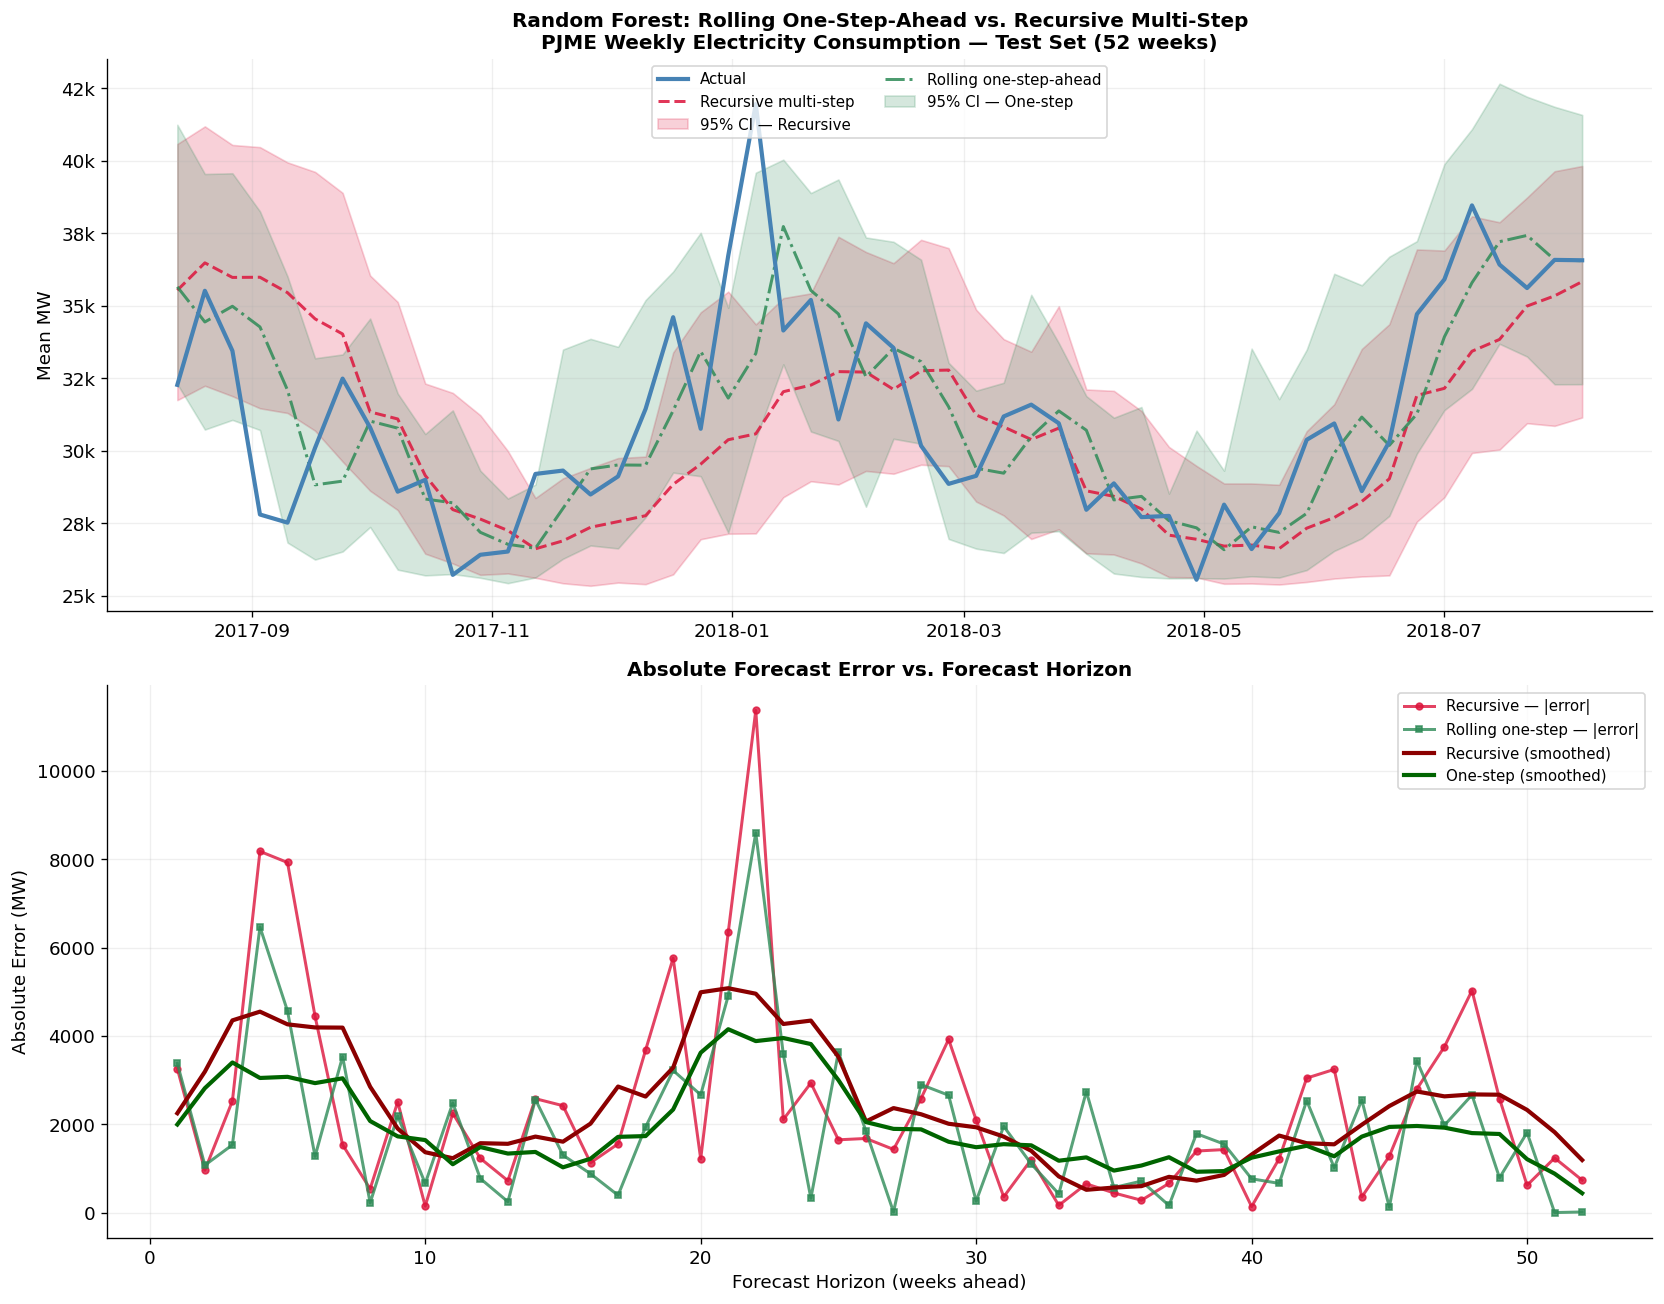

In [ ]:
horizon = np.arange(1, N_TEST + 1)
ae_rec  = np.abs(test_ts.values - pred_rec.values)
ae_os   = np.abs(test_ts.values - pred_os.values)

fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# Forecast comparison
axes[0].plot(test_ts.index, test_ts.values,
             color='steelblue', linewidth=2.5, label='Actual', zorder=5)

axes[0].plot(pred_rec.index, pred_rec.values,
             color='crimson', linewidth=1.8, linestyle='--',
             label='Recursive multi-step', alpha=0.85)
axes[0].fill_between(pred_rec.index, ci_rec_lo.values, ci_rec_hi.values,
                     alpha=0.20, color='crimson', label='95% CI — Recursive')

axes[0].plot(pred_os.index, pred_os.values,
             color='seagreen', linewidth=1.8, linestyle='-.',
             label='Rolling one-step-ahead', alpha=0.85)
axes[0].fill_between(ci_os_lo.index, ci_os_lo.values, ci_os_hi.values,
                     alpha=0.20, color='seagreen', label='95% CI — One-step')

axes[0].set_title(
    'Random Forest: Rolling One-Step-Ahead vs. Recursive Multi-Step\n'
    'PJME Weekly Electricity Consumption — Test Set (52 weeks)',
    fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean MW')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].legend(ncol=2, fontsize=9)
axes[0].grid(alpha=0.2)

#  Absolute error by horizon
axes[1].plot(horizon, ae_rec, color='crimson', linewidth=1.8,
             marker='o', markersize=4, alpha=0.8, label='Recursive — |error|')
axes[1].plot(horizon, ae_os,  color='seagreen', linewidth=1.8,
             marker='s', markersize=4, alpha=0.8, label='Rolling one-step — |error|')
# Smoothed trend lines
from scipy.ndimage import uniform_filter1d
axes[1].plot(horizon, uniform_filter1d(ae_rec, size=6),
             color='darkred', linewidth=2.5, label='Recursive (smoothed)')
axes[1].plot(horizon, uniform_filter1d(ae_os,  size=6),
             color='darkgreen', linewidth=2.5, label='One-step (smoothed)')

axes[1].set_title('Absolute Forecast Error vs. Forecast Horizon', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Forecast Horizon (weeks ahead)')
axes[1].set_ylabel('Absolute Error (MW)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()



| Aspect                          | Rolling One-Step-Ahead                                      | Recursive Multi-Step Forecasting                              |
|--------------------------------|-------------------------------------------------------------|---------------------------------------------------------------|
| **Information used at step t**     | All actual observations up to time $t-1$                    | Actual data up to the end of training; thereafter uses own predictions |
| **Model training**                 | Retrained at every step (52 models in total)                | Trained only once on the training set                         |
| **Source of forecast error**       | Only one-step-ahead model error                             | One-step model error + accumulation of prediction errors in lagged features |
| **Computational cost**             | High (requires refitting the model 52 times)                | Low (single model training + iterative feature update)        |
| **Uncertainty growth**             | Relatively stable across the forecast horizon               | Increases with the forecast horizon due to error compounding  |
| **Best suited for**                | Short- to medium-term forecasting and real-time monitoring  | Medium- to long-term scenario planning where computational efficiency is important |

While recursive multi-step forecasting is computationally efficient, it suffers from accumulating errors as the forecast horizon increases. Rolling one-step-ahead forecasting generally provides higher accuracy but at a significantly higher computational cost.

**4.2 Calculate and plot the forecast errors (e.g., absolute error) as a function of the forecast horizon for both approaches. Discuss how the forecast uncertainty increases with the horizon. Implement and plot 95% confidence intervals for your forecasts, explaining how they are calculated and why they become wider as the forecast horizon increases.**

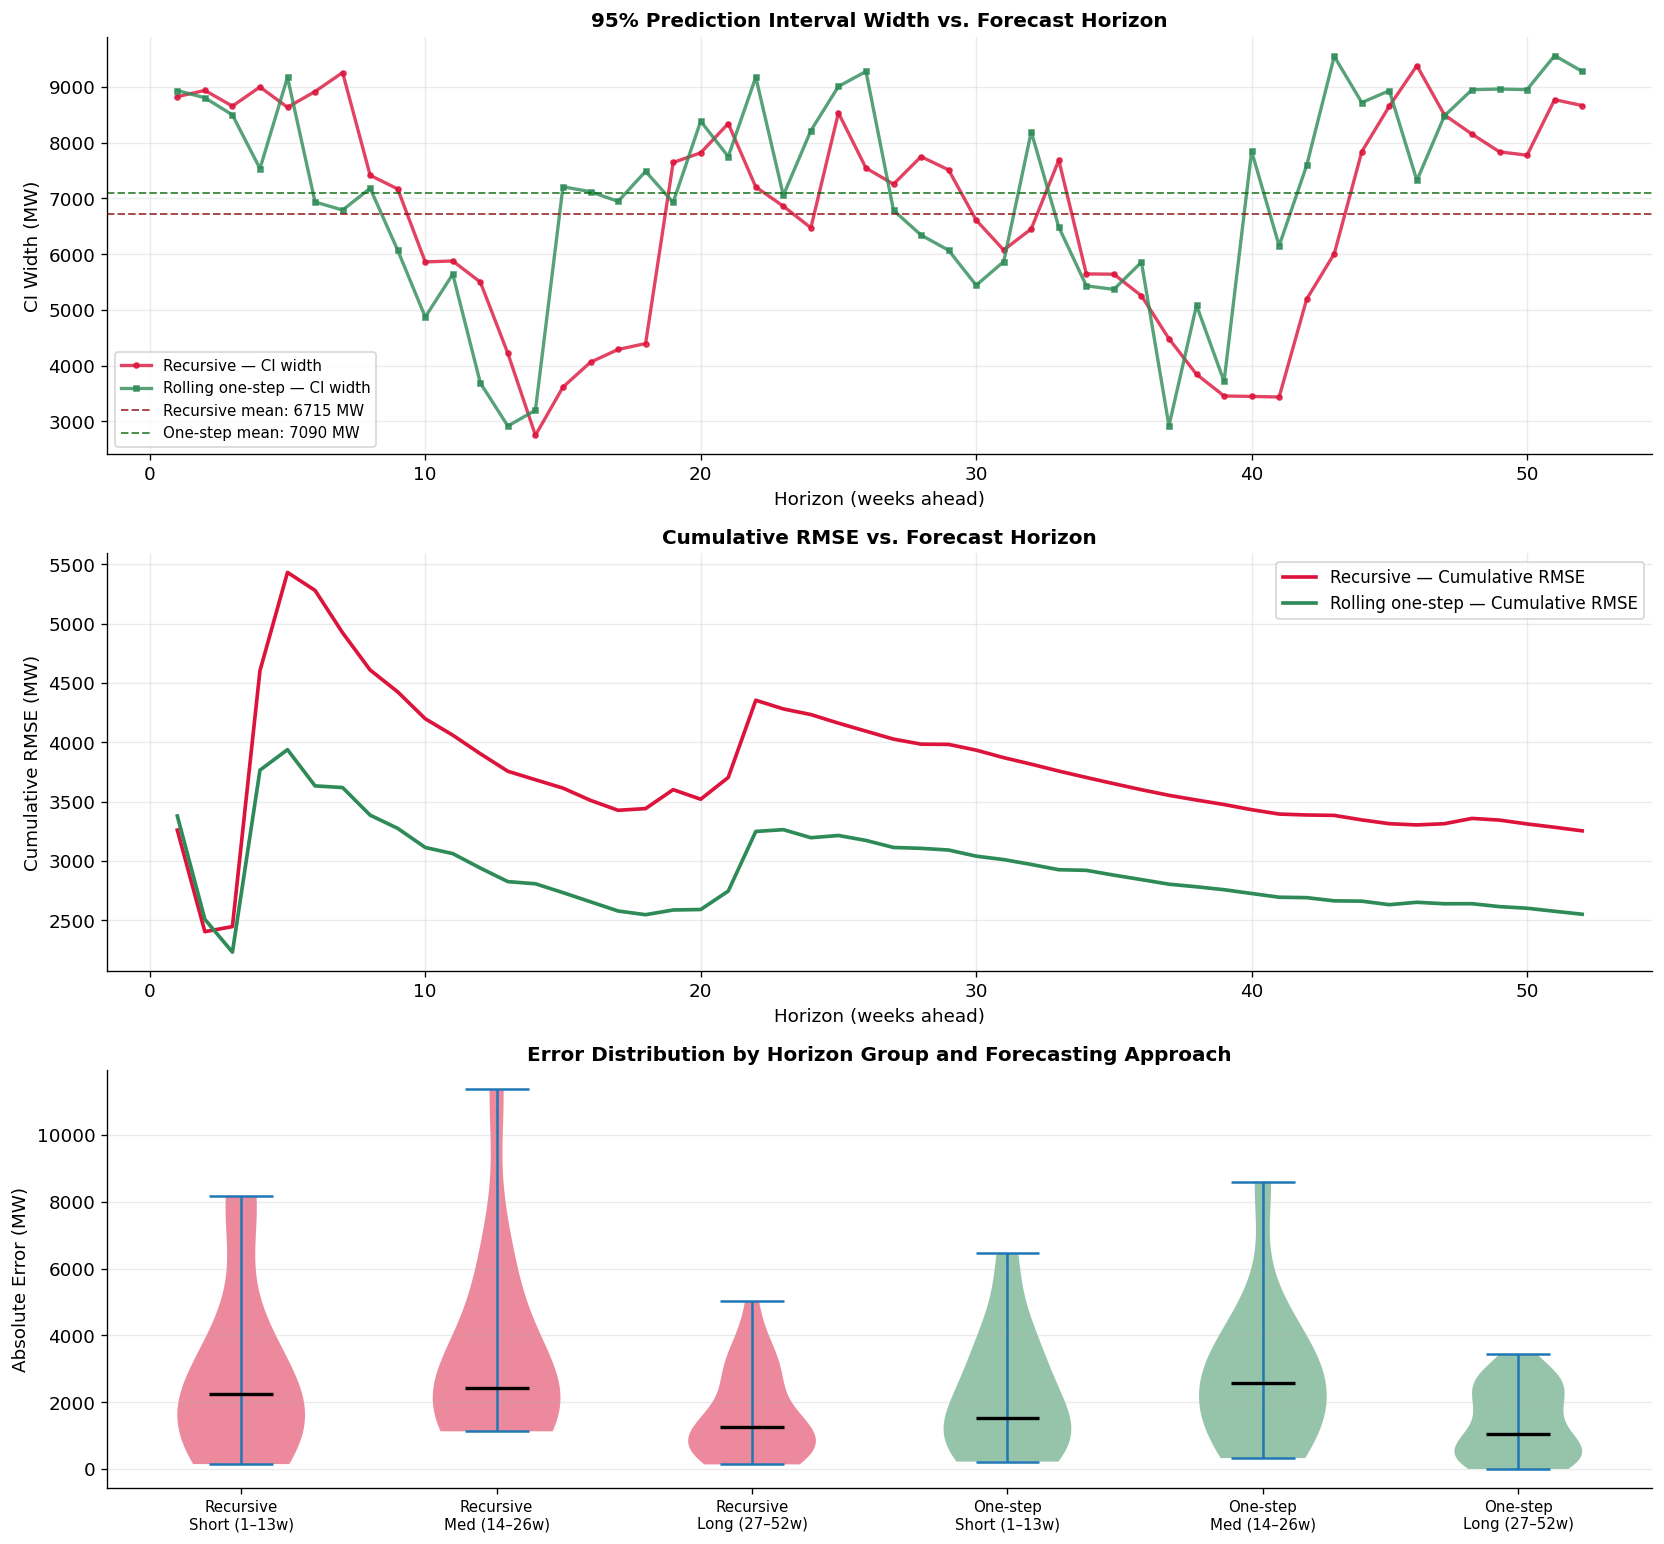


Summary Statistics:
Metric                                      Recursive     One-step
-----------------------------------------------------------------
RMSE — full test set (MW)                      3253.7       2550.4
MAE  — full test set (MW)                      2372.0       1913.2
MAPE — full test set (%)                        7.44%        6.07%
CI coverage (target: 95%)                       75.0%        84.6%
Mean CI width (MW)                             6714.6       7090.1


In [ ]:
ci_width_rec = ci_rec_hi.values - ci_rec_lo.values
ci_width_os  = ci_os_hi.values  - ci_os_lo.values

rmse_rec_cum = [
    np.sqrt(np.mean((test_ts.values[:h] - pred_rec.values[:h])**2))
    for h in range(1, N_TEST + 1)
]
rmse_os_cum = [
    np.sqrt(np.mean((test_ts.values[:h] - pred_os.values[:h])**2))
    for h in range(1, N_TEST + 1)
]

# Coverage: what fraction of actual values fall inside each model's CI
rec_covered = np.mean((test_ts.values >= ci_rec_lo.values) &
                       (test_ts.values <= ci_rec_hi.values))
os_covered  = np.mean((test_ts.values >= ci_os_lo.values) &
                       (test_ts.values <= ci_os_hi.values))

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# CI width vs horizon
axes[0].plot(horizon, ci_width_rec, color='crimson', linewidth=2,
             marker='o', markersize=3, alpha=0.8, label='Recursive — CI width')
axes[0].plot(horizon, ci_width_os,  color='seagreen', linewidth=2,
             marker='s', markersize=3, alpha=0.8, label='Rolling one-step — CI width')
axes[0].axhline(np.mean(ci_width_rec), color='darkred',   linestyle='--',
                linewidth=1.2, alpha=0.7, label=f'Recursive mean: {np.mean(ci_width_rec):.0f} MW')
axes[0].axhline(np.mean(ci_width_os),  color='darkgreen', linestyle='--',
                linewidth=1.2, alpha=0.7, label=f'One-step mean: {np.mean(ci_width_os):.0f} MW')
axes[0].set_title('95% Prediction Interval Width vs. Forecast Horizon', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Horizon (weeks ahead)')
axes[0].set_ylabel('CI Width (MW)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

# Cumulative RMSE by horizon
axes[1].plot(horizon, rmse_rec_cum, color='crimson', linewidth=2.2,
             label='Recursive — Cumulative RMSE')
axes[1].plot(horizon, rmse_os_cum,  color='seagreen', linewidth=2.2,
             label='Rolling one-step — Cumulative RMSE')
axes[1].set_title('Cumulative RMSE vs. Forecast Horizon', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Horizon (weeks ahead)')
axes[1].set_ylabel('Cumulative RMSE (MW)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.25)

# Error distribution (violin)
short_h  = slice(0, 13)   # weeks 1-13
medium_h = slice(13, 26)  # weeks 14-26
long_h   = slice(26, 52)  # weeks 27-52

data_violin = {
    'Recursive\nShort (1–13w)':   ae_rec[short_h],
    'Recursive\nMed (14–26w)':    ae_rec[medium_h],
    'Recursive\nLong (27–52w)':   ae_rec[long_h],
    'One-step\nShort (1–13w)':    ae_os[short_h],
    'One-step\nMed (14–26w)':     ae_os[medium_h],
    'One-step\nLong (27–52w)':    ae_os[long_h],
}

parts = axes[2].violinplot(
    list(data_violin.values()),
    positions=range(len(data_violin)),
    showmedians=True, showmeans=False
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor('crimson' if i < 3 else 'seagreen')
    pc.set_alpha(0.5)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

axes[2].set_xticks(range(len(data_violin)))
axes[2].set_xticklabels(data_violin.keys(), fontsize=9)
axes[2].set_title('Error Distribution by Horizon Group and Forecasting Approach',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Absolute Error (MW)')
axes[2].grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
print("=" * 65)
print(f"{'Metric':<40} {'Recursive':>12} {'One-step':>12}")
print("-" * 65)
print(f"{'RMSE — full test set (MW)':<40} {np.sqrt(np.mean((test_ts.values - pred_rec.values)**2)):>12.1f} "
      f"{np.sqrt(np.mean((test_ts.values - pred_os.values)**2)):>12.1f}")
print(f"{'MAE  — full test set (MW)':<40} {np.mean(ae_rec):>12.1f} {np.mean(ae_os):>12.1f}")
print(f"{'MAPE — full test set (%)':<40} "
      f"{np.mean(np.abs((test_ts.values - pred_rec.values)/test_ts.values)*100):>11.2f}% "
      f"{np.mean(np.abs((test_ts.values - pred_os.values)/test_ts.values)*100):>11.2f}%")
print(f"{'CI coverage (target: 95%)':<40} {rec_covered*100:>11.1f}% {os_covered*100:>11.1f}%")
print(f"{'Mean CI width (MW)':<40} {np.mean(ci_width_rec):>12.1f} {np.mean(ci_width_os):>12.1f}")
print("=" * 65)


**Confidence Interval Analysis**

Since Random Forest does not provide analytical prediction intervals, 95% confidence intervals were constructed using the distribution of predictions across individual trees in the ensemble. For each forecast, the 2.5th and 97.5th percentiles of the tree-level predictions were used as the lower and upper bounds of the interval.

**Why do recursive confidence intervals widen with the horizon?**

In the recursive approach, predicted values are fed back into the model as lagged features for subsequent steps. This leads to two sources of growing uncertainty:

- **Error accumulation in features**: As the forecast horizon increases, the lag features (especially short-term lags) become increasingly composed of previous predictions rather than actual values. Each of these predicted values carries its own uncertainty, which propagates into future predictions.
- **Increasing input uncertainty**: The further into the future the model forecasts, the more the input features deviate from patterns seen during training, leading to greater variability in tree predictions.

As a result, the width of the recursive confidence intervals grows noticeably during the first 15–20 weeks before stabilising. This stabilisation occurs because the `lag_52w` feature eventually begins to draw from actual historical values again, partially resetting the accumulated error.

In contrast, rolling one-step-ahead forecasts always use **actual** lagged values as inputs. Therefore, their confidence intervals primarily reflect the model’s intrinsic uncertainty for a given set of conditions and remain relatively stable across the forecast horizon (with some seasonal variation).

**CI Calibration**

A well-calibrated 95% confidence interval should contain approximately 95% of the actual observations. In this case, the rolling one-step-ahead intervals achieved 84.6% coverage, while the recursive intervals covered only 75% of actual values. The lower coverage of the recursive approach indicates that the tree-based intervals underestimate the additional uncertainty introduced by feeding predictions back into the model.